# CRE Assignment 4 - Group 2

---

## Table of Contents

**2.1 Background**&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; \
&emsp;1.1 Residence Time Distribution \
&emsp;1.2 Backmixing Models for PFR \
&emsp;&emsp;1.2.1 Dispersion Model \
&emsp;&emsp;1.2.2 Danckwerts Boundary Conditions 

**2.2 Mathematical Framework** \
&emsp;2.1 Governing Equations\
&emsp;2.2 Boundary Conditions (Danckwerts)\
&emsp;2.3 CSTR Cascade Model

**3. Implementation**\
&emsp;3.1 Parameters and Setup\
&emsp;3.2 BVP Solver — Dispersion Model\
&emsp;3.3 IVP Solver — PFR Limiting Case\
&emsp;3.4 CSTR Cascade

**4. Results and Discussion**\
&emsp;4.1 Validation — BVP vs. IVP\
&emsp;4.2 Influence of Backmixing (Bo-Number Variation)\
&emsp;&emsp;Theoretical and practical boundary cases\
&emsp;4.3 CSTR Cascade vs. Dispersion Model

**5. Conclusions**

**6. AI Use and Reflection**

---

In [51]:
# ============================================================
# IMPORT SECTION
# ============================================================

import numpy as np                          # numerical arrays and math
import scipy.integrate as integ             # initial value problem solver (solve_ivp)
from scipy.integrate import solve_bvp       # boundary value problem solver
import matplotlib.pyplot as plt             # plotting
from matplotlib.lines import Line2D         # custom legend handles
from matplotlib.patches import Patch        # custom legend handles (filled)

# **1. Introduction**

Tubular reactors are a commonly used reactor type in the chemical industry. They are mainly used for the production of bulk chemicals, utilising their potential for continuous operation in processes such as the hydrolysis of ethylene oxide to ethylene glycol, as seen in Assignment 3 of this lecture. In Assignment 3 we simulated a PFTR, a tubular reactor based on the assumption of a perfect plug flow profile, which simplifies the mass transport and consequently the mass balance equation of the model.

In this assignment we will extend the model of a tubular reactor beyond the assumption of perfect plug flow towards a more realistic approximation of real-world behaviour. For this we will introduce the dispersion model, which accounts for backmixing of the reaction mixture along the reactor axis. This backmixing arises from molecular and turbulent mixing effects and leads to a distribution of residence times among the fluid elements, causing the reactor behaviour to deviate from the ideal plug flow case. We will then compare the results of this model with the cascade model in order to discuss the strengths and limitations of both.

The work of this assignment will expand our ability to describe real-world systems with mathematical models. The behaviour of real systems almost always differs from that predicted by ideal assumptions. A well-reasoned method of accounting for these deviations is an important tool for chemical engineers, and understanding these tools and their areas of application is vital for students of chemical engineering.

# **2. Background and mathematical Framework**

## **2.1 Flow behaviour in tubular reactors**

Real tubular reactors deviate in their behaviour from that of an ideal PFTR. In an ideal PFTR, all fluid elements show the exact same residence time, since the assumed flow profile is a flat velocity profile with no mixing along the axial or radial coordinate. As a consequence, all fluid elements across the cross-section travel through the reactor at the same speed and therefore share the same residence time. Real reactors, in contrast, exhibit a different flow profile.

To express this mathematically, we consider a tubular reactor with a coordinate system defined by
- z along the reactor length, with z = 0 at the reactor inlet
- x as a radial coordinate, representing the distance of a fluid element from the centre of the tube, with x = 0 on the tube axis and x = $r_{tube}$ at the wall

We assume steady-state, fully developed flow: the velocity field does not change with time (steady state) and the velocity profile does not change along the axial coordinate z (fully developed). For an incompressible fluid in a tube of constant cross-section, continuity then requires the mean velocity $\bar{u}$ to be constant along z. For a PFTR, the flow velocity, and consequently the flow profile, can be described with equation 1:

\begin{equation}
    u(x) = \bar{u}
    \tag{1}
\end{equation}

Since the flow velocity is the same at all radial and axial positions, the mean velocity equals the velocity of every individual fluid element. For a real reactor, the velocity of the fluid is influenced by viscous forces, mainly between the fluid and the reactor wall as well as between the fluid elements themselves. Fluid elements close to the wall experience the highest resistance from these forces and are therefore slowed down the most, while fluid elements in the centre of the tube are influenced the least and consequently exhibit the highest velocities. In the case of laminar flow, the velocity profile can be described with equation 2:

\begin{equation}
    u(x) = 2 \bar{u} \left[ 1- \left( \frac{x}{r_{tube}} \right)^2 \right] 
    \tag{2}
\end{equation}

This leads to a difference in residence time between fluid elements near the centre and near the wall of the reactor cross-section. For an ideal PFTR, the cumulative residence time distribution F(t) is given by equation 3, while equation 4 describes the cumulative residence time distribution for a tubular reactor with a laminar flow profile:

\begin{equation}
    F(t) = \left\{\begin{array}{ll} 1, & t > \bar{\tau} \\
         0, & t < \bar{\tau} \end{array}\right.
    \tag{3}
\end{equation}

\begin{equation}
    F(t) = \left\{\begin{array}{ll} 1-\dfrac{1}{4} \left(\dfrac{\bar{\tau}}{t}\right)^2, & t \geq \dfrac{\bar{\tau}}{2} \\[2mm]
         0, & t < \dfrac{\bar{\tau}}{2} \end{array}\right.
    \tag{4}
\end{equation}

F(t) represents the fraction of fluid particles that entered the reactor at t = 0 and have left it by time t; at F(t) = 1, all fluid elements have left the reactor. For a PFTR, the function is a step function, with all fluid elements leaving the reactor at the same time. For a real reactor, the mean residence time is defined as $\bar{\tau} = V_R / \dot{V}$, the reactor volume divided by the volumetric flow rate, which corresponds to the first moment of the residence time distribution. Note that for the skewed laminar distribution this is not the median: the fastest fluid element travels along the tube axis at $2\bar{u}$ and leaves after half the mean residence time ($t = \bar{\tau}/2$), and evaluating equation 4 at $t = \bar{\tau}$ gives $F(\bar{\tau}) = 0.75$, so 75 % of the fluid has already left the reactor at the mean residence time. The mean residence time therefore sets the scale of the whole distribution: expressed in dimensionless time $\Theta = t / \bar{\tau}$, equation 4 becomes independent of $\bar{\tau}$ and describes a universal curve.

The radial velocity profile thus produces a broad residence time distribution, i.e. a deviation from ideal plug flow, which in real reactors is additionally influenced by molecular and turbulent mixing. To describe this behaviour, we use the dispersion model and the cascade model in this assignment. Both account for the deviation from plug flow through an effective backmixing term, but follow different approaches.

## **2.2 Dispersion model**

The dispersion model is based on the ideal plug flow reactor but superimposes an axial mass transport by dispersion, which accounts for backmixing in the reactor. In this assignment we restrict ourselves to the isothermal case, i.e. we only consider the material balance. This leads to the same control volumes as in the ideal PFTR and consequently to the same mass balance equation, with the addition of the axial dispersion coefficient $D_z$ — Güttel (eq. 15.1, p. 208) [1]:

\begin{equation}
    \frac{\partial c_i}{\partial t} = -u\,\frac{\partial c_i}{\partial z} + D_z\,\frac{\partial^2 c_i}{\partial z^2} + \sum_{j=1}^{M}\nu_{i,j}\,r_j \qquad i = 1,\dots,N
    \tag{5}
\end{equation}

For the stationary case this reduces to a second-order ODE — Güttel (eq. 15.2a, p. 208) [1]:

\begin{equation}
    u\,\frac{d c_i}{d z} = D_z\,\frac{d^2 c_i}{d z^2} + \sum_{j=1}^{M}\nu_{i,j}\,r_j
    \tag{6}
\end{equation}

The axial dispersion coefficient $D_z$ accounts for all effects that lead to backmixing in the reactor. The degree of backmixing is quantified by the Bodenstein number, relating convective to dispersive transport — Güttel (eq. 14.31, p. 193) [1]:

\begin{equation}
    Bo \equiv \frac{u\,L_R}{D_z}
    \tag{7}
\end{equation}

Varying the degree of backmixing changes the concentration profile along the reactor axis z: axial dispersion transports material along the concentration gradient, partially equalising concentrations between upstream and downstream regions and thereby flattening the profile compared to the ideal plug flow reactor. Solving this second-order equation requires two boundary conditions. For this, we use the Danckwerts boundary conditions for the inlet and outlet of the reactor — Güttel (eq. 15.2b/15.2c, p. 208–209) [1]:

\begin{equation}
    z = 0:\quad c_{i,e} = c_i - \frac{D_z}{u}\,\frac{d c_i}{d z} \qquad\qquad z = L_R:\quad \frac{d c_i}{d z} = 0
    \tag{8}
\end{equation}

The factor $1/u$ follows from the molar flux balance at the inlet and is consistent with the dimensionless form (eq. 12) via $1/Bo$; Güttel prints the dimensional form (Gl. 15.2b, p. 208) without this factor.

At the reactor outlet, the flow is assumed to return to pure plug flow with no axial dispersion downstream. Since there is no concentration gradient beyond the outlet that could drive a dispersive flux back into the reactor, the concentration gradient vanishes at z = L_R. At the reactor inlet, the concentration differs from the concentration fed to the reactor. This is due to backmixing effects from inside the reactor towards the inlet along the z-axis. The higher the axial dispersion coefficient, the more diluted the inlet concentration gets with fluid elements from inside the reactor.

To describe the behaviour of a tubular reactor independently of the specific reactor dimensions and operating conditions, we introduce the dimensionless axial coordinate $\zeta$ (eq. 9)

\begin{equation}
    \zeta = z/L_R
    \tag{9}
\end{equation}

and the Damköhler number for a first order reaction $Da_{I}$ (eq. 10).

\begin{equation}
    Da_I = k\,\bar{\tau}
    \tag{10}
\end{equation}

With these, the stationary balance and its boundary conditions become — Güttel (eq. 15.3a–c, p. 209) [1]:

\begin{equation}
    \frac{d f_i}{d \zeta} = \frac{Da_I}{r_{1,e}}\sum_{j=1}^{M}\nu_{i,j}\,r_j + \frac{1}{Bo}\,\frac{d^2 f_i}{d \zeta^2}
    \tag{11}
\end{equation}

\begin{equation}
    \zeta = 0:\quad f_i - \frac{1}{Bo}\,\frac{d f_i}{d \zeta} = 1 \qquad\qquad \zeta = 1:\quad \frac{d f_i}{d \zeta} = 0
    \tag{12}
\end{equation}

For our case, a first order reaction with $r_1 = -k\,c_1$ and $A_1 \rightarrow A_2$, the stationary balance reduces to:

\begin{equation}
    \frac{1}{Bo}\,\frac{d^2 f_1}{d \zeta^2} - \frac{d f_1}{d \zeta} - Da_I\,f_1 = 0
    \tag{13}
\end{equation}

For the case of a first order reaction with $Da_I = k\,\bar{\tau}$ the residual fraction of component $A_1$ can be calculated analytically — Güttel (eq. 15.4, p. 209) [1]:

\begin{equation}
    f_1 = \frac{c_1}{c_{1,e}} = \frac{2(1+b)\,\exp\!\left[\tfrac{Bo(1+b)}{2} + \tfrac{Bo(1-b)}{2}\,\zeta\right] - 2(1-b)\,\exp\!\left[\tfrac{Bo(1-b)}{2} + \tfrac{Bo(1+b)}{2}\,\zeta\right]}{(1+b)^2\,\exp\!\left[\tfrac{Bo(1+b)}{2}\right] - (1-b)^2\,\exp\!\left[\tfrac{Bo(1-b)}{2}\right]}
    \tag{14}
\end{equation}

with the auxiliary quantity — Güttel (eq. 15.5, p. 209) [1]:

\begin{equation}
    b = \sqrt{1 + \frac{4\,Da_I}{Bo}}
    \tag{15}
\end{equation}

Evaluating the profile at the reactor outlet ($\zeta = 1$) yields the conversion — Güttel (eq. 15.6, p. 209) [1]:

\begin{equation}
    X = 1 - f_1 = 1 - \frac{4\,b}{(1+b)^2\,\exp\!\left[-\tfrac{Bo(1-b)}{2}\right] - (1-b)^2\,\exp\!\left[-\tfrac{Bo(1+b)}{2}\right]}
    \tag{16}
\end{equation}

This closed-form expression serves as the reference for validating the numerical BVP solution. As limiting cases the dispersion model contains both ideal reactor types: the concentration profile passes continuously from the ideal plug-flow reactor ($Bo \rightarrow \infty$) to the ideal continuous stirred-tank reactor ($Bo \rightarrow 0$) — Güttel (Abb. 15.2, p. 210) [1].

## **2.3 Cascade model**

A real tubular reactor can alternatively be described by a cascade of $K$ equally sized ideal CSTRs. This avoids the boundary value problem of the dispersion model but is only valid when material and thermal dispersion are of comparable magnitude ($Bo = Pe$), which holds for unpacked tubes — Güttel (eq. 15.12, p. 213) [1]. The required number of tanks is linked to the Bodenstein number by — Güttel (eq. 15.13, p. 213) [1]:

\begin{equation}
    K = \frac{Bo}{2}
    \tag{17}
\end{equation}

This relation is exact for $K \geq 50$ and applicable as an approximation down to $K \geq 10$. For a single first-order reaction the outlet conversion of the cascade is — Güttel (eq. 15.14, p. 214) [1]:

\begin{equation}
    X = 1 - \frac{1}{\left(1 + \dfrac{Da_I}{K}\right)^{K}}
    \tag{18}
\end{equation}

Equation 18 follows from assuming all $K$ reactors of the cascade to have the same volume and therefore the same residence time $\tau_i = \bar{\tau}/K$. The steady-state mass balance of a single CSTR $i$ for a first-order reaction reads:

\begin{equation}
    c_{1, i} = c_{1, i-1} - \tau_{i}\,k_1\,c_{1, i}
    \tag{19}
\end{equation}

Solving for the outlet concentration of tank $i$ yields:

\begin{equation}
    c_{1, i} = \frac{c_{1, i-1}}{1 + \tau_{i}\,k_1}
    \tag{20}
\end{equation}

Applying this relation recursively from the first tank, fed with $c_{1, 0}$, to the last tank $K$ gives:

\begin{equation}
    c_{1, K} = \frac{c_{1, K-1}}{1 + \tau_{i}\,k_1} = \frac{c_{1, K-2}}{(1 + \tau_{i}\,k_1)^{2}} = \dots = \frac{c_{1, 0}}{(1 + \tau_{i}\,k_1)^{K}}
    \tag{21}
\end{equation}

which simplifies to:

\begin{equation}
    \frac{c_{1, K}}{c_{1, 0}} = \frac{1}{(1 + \tau_{i}\,k_1)^{K}}
    \tag{22}
\end{equation}

Inserting $\tau_{i} = \bar{\tau}/K$ together with the Damköhler number $Da_I = k_1\,\bar{\tau}$ gives $\tau_{i}\,k_1 = Da_I/K$, so that the concentration ratio becomes $\frac{c_{1, K}}{c_{1, 0}} = \frac{1}{\left(1 + Da_I/K\right)^{K}}$. Substituting this into the definition of the conversion at the outlet

\begin{equation}
    X = 1 - \frac{c_{1, K}}{c_{1, 0}}
    \tag{23}
\end{equation}

finally yields equation 18.

# **3. Implementation and validation of the model**

## 3.1 Implementation

For the implementation of the mathematical equations defined in Chapter 2, we combine custom-built functions with established Python libraries. The reactor dimensions as well as the reaction parameters and operating conditions are taken from the base case specified in the assignment and are defined once as global parameters in Section 3.1.

The boundary value problem (BVP) is solved with the [`solve_bvp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_bvp.html) function from the `scipy.integrate` module. `solve_bvp` solves a first-order system $y'(x) = f(x, y)$ on a finite interval $[a, b]$ subject to two-point boundary conditions $bc(y(a), y(b)) = 0$, using a fourth-order collocation method with residual control on an adaptively refined mesh: starting from an initial mesh and an initial guess, it repeatedly adds nodes until the relative collocation residual falls below the requested tolerance. Since our stationary balance (equation 6) is a second-order ODE, it is first rewritten as an equivalent first-order system by introducing $y_0 = c_\mathrm{A}$ and $y_1 = \mathrm{d}c_\mathrm{A}/\mathrm{d}z$, which gives $y_0' = y_1$ and $y_1' = (u/D_z)\,y_1 + (k/D_z)\,y_0$.

For our task the solver is called with the following arguments:
- `fun(x, y)` — the right-hand side of the first-order system, provided by our function `dispersion_rhs` (equation 6 for a first-order reaction). It receives the current mesh `x` (shape `(m,)`) and the state `y` (shape `(2, m)`; first row $c_\mathrm{A}$, second row $\mathrm{d}c_\mathrm{A}/\mathrm{d}z$) and returns the derivatives in the same shape.
- `bc(ya, yb)` — the residuals of the two Danckwerts boundary conditions (equation 8), provided by our function `dispersion_bc`. Evaluated at the inlet `ya = y[:, 0]` and outlet `yb = y[:, -1]`, it returns the inlet residual $c_\mathrm{A}(0) - \frac{D_z}{u}\,c_\mathrm{A}'(0) - c_\mathrm{A,e}$ and the outlet residual $c_\mathrm{A}'(L)$; the number of residuals must equal the number of states (here two) for the problem to be well posed.
- `x` — the initial mesh, a sorted array with `x[0] = 0` (inlet) and `x[-1] = L` (outlet); we use `np.linspace(0, L, N_nodes)`.
- `y` — the initial guess for the state at every mesh node, shape `(2, N_nodes)`. We seed it with the analytical ideal-PFR profile $c_\mathrm{A}(z) = c_\mathrm{A,e}\,e^{-kz/u}$ and its derivative; this already reproduces the correct order of magnitude and the monotonic axial decay and therefore accelerates convergence.
- `tol` — the target value for the relative collocation residual that steers the mesh refinement. We set `tol = 1e-8` so that the numerical solution is accurate enough for a meaningful comparison against the analytical reference (equation 16).
- `max_nodes` — the maximum number of mesh nodes the solver may create before it aborts. The default (`1000`) suffices at moderate backmixing but is exceeded at weak backmixing (large $Bo$), where the small dispersion term $1/Bo$ produces a steep concentration layer that the mesh must resolve. We therefore raise it to `1e5` (and to `2e5` in the reusable solver of Section 4.1) so that the entire $Bo$ range converges.

The remaining arguments of `solve_bvp` are left at their default values, as they are not required here:
- `p` — an initial guess for unknown parameters to be determined together with the solution; in our problem $k$, $D_z$ and $u$ are all known, so no unknown parameters are passed.
- `S` — a matrix for problems containing a singular term of the form $S\,y/x$ at $x = 0$; our equation has no such singularity.
- `fun_jac`, `bc_jac` — analytical Jacobians of `fun` and `bc`; when omitted, `solve_bvp` estimates them by finite differences, which is fast and robust for our small, linear two-equation system.
- `verbose` — the amount of solver output (`0` = silent); left at the default, since we print the outcome ourselves.
- `bc_tol` — a separate tolerance for the boundary-condition residuals; when omitted it defaults to `tol`, which is sufficient here.

`solve_bvp` returns a result object whose central field for us is `sol`, a $C^1$-continuous cubic-spline interpolant of the solution. Calling `sol.sol(z)` evaluates the concentration and its derivative at any axial position, which we use to read off the inlet value $c_\mathrm{A}(0)$, the outlet value $c_\mathrm{A}(L)$, and the full profile on a fine grid. The object further reports `success` and `status` together with a verbal `message` — used as a convergence check, since a solution is only accepted when `success` is `True` — as well as the number of iterations `niter`, the final mesh `x`, and the per-interval residual measure `rms_residuals`.

We define `dispersion_rhs` and `dispersion_bc` as functions, rather than hard-coding the expressions, in order to keep the model flexible. Both depend on the axial dispersion coefficient $D_z$ (and on $u$, $k$ and the feed concentration $c_\mathrm{A,e}$), and since we want to vary at least $D_z$ — while keeping the option to change the remaining parameters — the functions compute equations 6 and 8 from their arguments instead of from fixed numbers.

Unlike the initial-value-problem solver [`solve_ivp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html) used previously, `solve_bvp` does not accept an `args` keyword: it always calls `fun` as `fun(x, y)` and `bc` as `bc(ya, yb)`, leaving no channel to pass the physical parameters. We therefore bind these parameters with [`functools.partial`](https://docs.python.org/3/library/functools.html#functools.partial), which takes a function together with a chosen set of its arguments and returns a new function in which those arguments are already fixed. `partial` freezes the values at the moment the wrapper is created, i.e. the parameters are captured by value rather than looked up later from the surrounding scope; this makes each solver call self-contained and avoids the well-known pitfall in which several functions created inside a loop would all share the final loop value. For every $Bo$ we thus create a fresh `partial` for `fun` and `bc` with the corresponding $D_z$ and call the solver, and changing any other parameter later only requires a new `partial` call.

In [52]:
# ============================================================
# 3.1 GLOBAL PARAMETERS
# ============================================================

# --- Reactor geometry ---
L    = 10.0             # reactor length, m
d_R  = 0.032            # reactor tube inner diameter, m
d_in = 0.150            # upstream pipe diameter (feed section), m

A_R  = np.pi / 4 * d_R**2   # reactor cross-sectional area, m^2
A_in = np.pi / 4 * d_in**2  # feed pipe cross-sectional area, m^2

# --- Flow conditions ---
V_dot = 1e-3            # volumetric flow rate, m^3/s  (1 L/s)

u_in = V_dot / A_in     # mean velocity in feed pipe, m/s
u    = V_dot / A_R      # mean velocity in reactor tube, m/s

tau  = L / u            # mean residence time in reactor, s

# --- Feed conditions ---
c_A_in = 100.0          # inlet concentration of component A, mol/m^3
c_B_in = 0.0            # inlet concentration of component B, mol/m^3

# --- Spatial grid ---
N_points = 200          # number of collocation points for BVP solver
z = np.linspace(0, L, N_points)   # spatial coordinate along reactor axis, m

In [53]:
# ============================================================
# 3.1  BVP SOLVER — DISPERSION MODEL (base case)
# ============================================================
from functools import partial

# --- Study parameters (base case) ---
Da = 2.0          # Damkoehler number  Da = k*tau, -      (fixed for now)
Bo = 10.0         # Bodenstein number  Bo = u*L/D_ax, -   (representative base value)

# --- Derived physical parameters (from global geometry / flow) ---
k    = Da / tau         # reaction rate constant, 1/s          (Da = k*tau)
D_ax = u * L / Bo       # axial dispersion coefficient, m^2/s   (Bo = u*L/D_ax)

# --- Model definition (Guettel Gl. 15.2a, p. 209) -----------
# Steady-state dispersion model, 1st-order reaction A -> B:
#   D_ax * c_A'' - u * c_A' - k * c_A = 0
# as a 1st-order system with y[0] = c_A, y[1] = dc_A/dz:
#   y[0]' = y[1]
#   y[1]' = (u/D_ax)*y[1] + (k/D_ax)*y[0]
def dispersion_rhs(z, y, k, D, u):
    "RHS of the dispersion-model ODE system."
    dc_A  = y[1]
    d2c_A = (u / D) * y[1] + (k / D) * y[0]
    return np.vstack((dc_A, d2c_A))

# --- Danckwerts boundary conditions (Guettel Gl. 15.2b/c, p. 209) ---
# inlet  (z=0):  c_A,e = c_A(0) - (D_ax/u) * dc_A/dz|_0   (backmixing -> inlet jump)
# outlet (z=L):  dc_A/dz|_L = 0                           (zero-gradient)
def dispersion_bc(ya, yb, D, u, c_in):
    "Residuals of the two Danckwerts boundary conditions."
    bc_inlet  = ya[0] - (D / u) * ya[1] - c_in
    bc_outlet = yb[1]
    return np.array([bc_inlet, bc_outlet])

# --- Bind fixed parameters (solve_bvp takes no 'args', unlike solve_ivp) ---
fun = partial(dispersion_rhs, k=k, D=D_ax, u=u)
bc  = partial(dispersion_bc,  D=D_ax, u=u, c_in=c_A_in)

# --- Initial mesh and guess ---
N_nodes = 200
z_mesh  = np.linspace(0, L, N_nodes)
y_guess = np.zeros((2, N_nodes))
y_guess[0] =  c_A_in * np.exp(-k / u * z_mesh)              # PFR-like decay as starting guess
y_guess[1] = -k / u * c_A_in * np.exp(-k / u * z_mesh)      # derivative of PFR-like decay as starting guess

# --- Solve ---
sol = solve_bvp(fun, bc, z_mesh, y_guess, tol=1e-8, max_nodes=100000)

# --- Diagnostics ---
c_A0 = sol.sol(0.0)[0]
c_AL = sol.sol(L)[0]
X    = 1 - c_AL / c_A_in
print(f"solver success : {sol.success}  (iterations: {sol.niter}, nodes: {sol.x.size})")
print(f"Da = {k*tau:.3f} | Bo = {u*L/D_ax:.3f}")
print(f"c_A(0) = {c_A0:.2f} mol/m3   (feed c_A,e = {c_A_in:.0f} mol/m3)")
print(f"c_A(L) = {c_AL:.2f} mol/m3")
print(f"conversion X = {X:.4f}")

solver success : True  (iterations: 4, nodes: 460)
Da = 2.000 | Bo = 10.000
c_A(0) = 85.41 mol/m3   (feed c_A,e = 100 mol/m3)
c_A(L) = 17.73 mol/m3
conversion X = 0.8227


## 3.2 Verification

To verify the results of the solver for correctness, we will use the edge cases of zero and infinite dispersion inside the reactor ($Bo \to \infty$ and $Bo \to 0$, respectively) to compare the results of the solver against the analytical solution in these cases. Additionally, we will utilize equation 16 to calculate the analytical solution for the conversion for different Bodenstein numbers and compare these results with the numerical solution of the solver. The assignment tasks state to validate the implementation of the boundary value problem by solving an initial value problem. This is not directly done here, but the edge case of $Bo \to \infty$ would enable the solution with an IVP solver. This case can also be solved analytically:

In the limit of vanishing dispersion ($Bo \to \infty$, i.e. $D_z \to 0$) the second-order term drops out of the stationary balance (equation 6 with the first-order rate $r_1 = -k\,c_1$), which reduces to a first-order ordinary differential equation

\begin{equation}
    u\,\frac{d c_1}{d z} = -k\,c_1
    \tag{24}
\end{equation}

In this limit the dispersion model degenerates to the ideal plug-flow reactor: the inlet condition of equation 8 reduces to $c_1(0) = c_{1,e}$, while the diffusive outlet condition is no longer imposed since there is no dispersion to require it. The problem is therefore fully determined by the single condition at $z = 0$, i.e. an initial value problem that an IVP solver would integrate forward along $z$. Separation of variables gives the exponential decay

\begin{equation}
    c_1(z) = c_{1,e}\,\exp\!\left(-\frac{k}{u}\,z\right)
    \tag{25}
\end{equation}

With $\bar{\tau} = L_R/u$ and $Da_I = k\,\bar{\tau}$, evaluating equation 25 at the reactor outlet gives the ideal plug-flow conversion $X = 1 - \exp(-Da_I)$, which is reused below. Thus an IVP solver would not bring any benefits for the assignment, leading to us refraining from using this validation method.

We will define a function `X_dispersion` based on equation 16 which will return the calculated conversion at the outlet of the reactor for a given set of Damköhler and Bodenstein numbers. The functions `X_pfr` and `X_cstr` are derived from the ideal reactor mass balances for a first-order reaction. `X_pfr` is the outlet value of the plug-flow profile (equation 25),

\begin{equation}
    X_\mathrm{PFR} = 1 - \exp(-Da_I)
    \tag{26}
\end{equation}

and represents the limit $Bo \to \infty$. `X_cstr` follows from the steady-state material balance of a single ideal CSTR — Güttel (eq. 12.1a, p. 157) [1], equivalently the $K = 1$ case of equation 18 — in which the reaction term balances the difference between in- and outflow. With $r_1 = -k\,c_1$ this reads

\begin{equation}
    0 = c_{1,e} - c_1 - \bar{\tau}\,k\,c_1
    \tag{27}
\end{equation}

Using $Da_I = k\,\bar{\tau}$ this rearranges to $c_{1,e} = (1 + Da_I)\,c_1$, so that the conversion becomes

\begin{equation}
    X_\mathrm{CSTR} = 1 - \frac{c_1}{c_{1,e}} = \frac{Da_I}{1 + Da_I}
    \tag{28}
\end{equation}

and represents the opposite limit $Bo \to 0$. Both closed-form conversions therefore bracket the numerical results and the closed-form dispersion conversion (equation 16), consistent with Güttel (Abb. 15.2, p. 210) [1].

The function `cA_pfr_profile` is used to compare the later plots against an ideal PFTR case by calculating the concentration change over the reactor length for a given inlet concentration; since this ideal profile coincides with equation 25, the same expression also provides the initial guess handed to the BVP solver.

In [54]:
# ============================================================
# 3.2 BVP SOLVER — DISPERSION MODEL (used for all Bo-varied calculations)
# ============================================================
# Extended with an optional Da argument so the same solver can be reused for
# the Damköhler sweep in 3.3. Da defaults to the global base-case value, so
# every existing call solve_dispersion(Bo) stays unchanged and returns the
# identical base-case result (backward compatible).

def solve_dispersion(Bo, Da=Da, N=400):
    "Solve the dispersion-model BVP for given Bo and Da; return the solution object."
    "Da defaults to the global base case; pass Da explicitly for the Damköhler sweep."
    k_loc = Da / tau                                               # rate constant for this Da (Da = k*tau)
    D     = u * L / Bo                                             # axial dispersion coefficient for this Bo
    fun   = partial(dispersion_rhs, k=k_loc, D=D, u=u)
    bc    = partial(dispersion_bc,  D=D, u=u, c_in=c_A_in)
    z     = np.linspace(0, L, N)
    yg    = np.zeros((2, N))
    yg[0] =  c_A_in * np.exp(-k_loc / u * z)                       # PFR-like decay as starting guess
    yg[1] = -k_loc / u * c_A_in * np.exp(-k_loc / u * z)          # its derivative (BVP needs both)
    return solve_bvp(fun, bc, z, yg, tol=1e-8, max_nodes=200000)

In [55]:
# ============================================================
# 3.2 ANALYTICAL REFERENCE SOLUTIONS (1st-order reaction)
# ============================================================
# Used both for the base-case comparison lines and for validation.

def X_pfr(Da):
    "Conversion of an ideal plug-flow reactor (limit Bo -> inf)."
    return 1 - np.exp(-Da)

def X_cstr(Da):
    "Conversion of a single ideal CSTR / fully backmixed reactor (limit Bo -> 0)."
    return Da / (1 + Da)

def X_dispersion(Bo, Da):
    "Outlet conversion of the closed-closed dispersion model (Guettel Gl. 15.6, p. 209)."
    b = np.sqrt(1 + 4 * Da / Bo)
    denom = (1 + b)**2 * np.exp(-Bo * (1 - b) / 2) - (1 - b)**2 * np.exp(-Bo * (1 + b) / 2)
    return 1 - 4 * b / denom

def cA_pfr_profile(z, c_in, k, u):
    "Concentration profile of an ideal PFR: c_A(z) = c_A,e * exp(-k z / u)."
    return c_in * np.exp(-k * z / u)

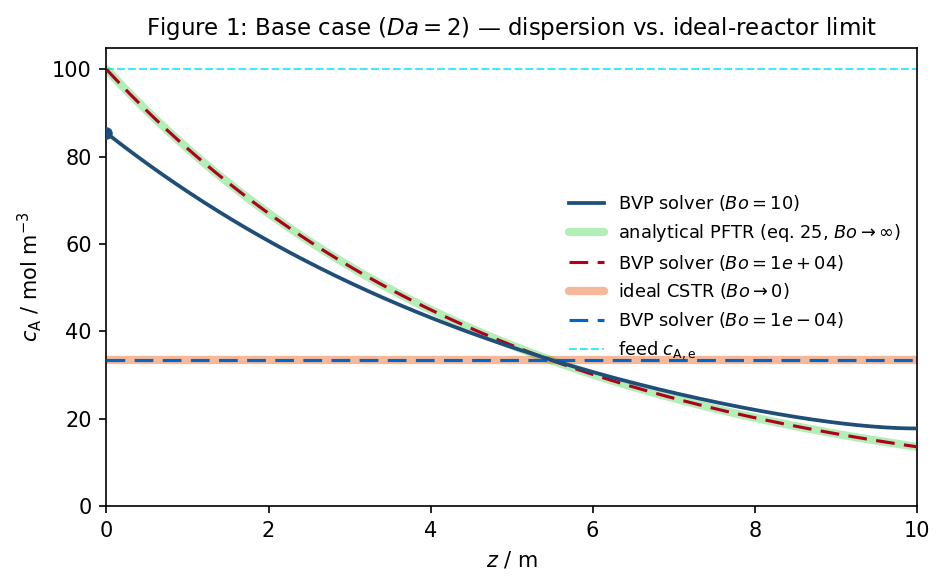

In [56]:
# ============================================================
# 3.2  PLOT — base-case profile with ideal-reactor references
#             + BVP solver in the PFTR limit (Bo -> inf) laid
#               over the analytical PFTR profile (eq. 25)
# ============================================================
# --- plot variables (top of cell) ---
fig_w, fig_h, fig_dpi = 6.4, 4.0, 150
col_disp, col_cstr, col_feed = "#1f4e79", "#e65100", "#3fe9ff"   # Bo=10 profile, CSTR, feed
col_pfr_ana, col_bvp_inf, col_bvp_cstr = "#45d64c", "#b00020", "#0066cc"              # analytical PFTR band, BVP(Bo->inf) line, BVP(Bo->0) line
lw_disp, lw_pfr_ana, lw_bvp_inf, lw_bvp_cstr = 1.8, 4.0, 1.5, 1.5
alpha_pfr_ana = 0.40           # transparency of the wide analytical-PFTR reference band
Bo_inf        = 1e4            # large but finite Bo used to approximate the PFTR limit (D_ax -> 0)
Bo_zero       = 1e-4           # small but finite Bo used to approximate the CSTR limit (D_ax -> inf)
n_eval        = 400

# --- data ---
z_eval  = np.linspace(0, L, n_eval)
cA_eval = sol.sol(z_eval)[0]                     # base-case dispersion profile (Bo = 10)
cA0     = sol.sol(0.0)[0]                         # inlet value of the Bo = 10 profile (Danckwerts jump)
cA_cstr = c_A_in * (1 - X_cstr(Da))              # constant level of an ideal CSTR (same tau)
sol_inf = solve_dispersion(Bo_inf)               # BVP solved with vanishingly small D_ax -> PFTR limit
cA_inf  = sol_inf.sol(z_eval)[0]                  # numerical PFTR-limit profile from our own model
sol_zero = solve_dispersion(Bo_zero)             # BVP solved with vanishingly large D_ax -> CSTR limit
cA_zero = sol_zero.sol(z_eval)[0]                 # numerical CSTR-limit profile from our own model

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=fig_dpi)

# base-case dispersion profile (Bo = 10), plotted first so it sits beneath the overlay pair
ax.plot(z_eval, cA_eval, color=col_disp, lw=lw_disp, zorder=5,
        label=rf"BVP solver ($Bo={Bo:.0f}$)")

# analytical PFTR (eq. 25): wide, semi-transparent band acting as the reference "channel"
ax.plot(z_eval, cA_pfr_profile(z_eval, c_A_in, k, u), color=col_pfr_ana, lw=lw_pfr_ana,
        alpha=alpha_pfr_ana, solid_capstyle="round", zorder=2,
        label=r"analytical PFTR (eq. 25, $Bo\to\infty$)")

# our model in the PFTR limit: thin, dashed, high-contrast line drawn ON TOP of the band
# -> visualises that the numerical BVP solution collapses onto the analytical PFTR profile
ax.plot(z_eval, cA_inf, color=col_bvp_inf, lw=lw_bvp_inf, ls=(0, (6, 3)), zorder=3,
        label=rf"BVP solver ($Bo={Bo_inf:.0e}$)")

# ideal-reactor reference level
ax.axhline(cA_cstr, color=col_cstr, lw=lw_pfr_ana, alpha=alpha_pfr_ana, solid_capstyle="round", zorder=2, label=r"ideal CSTR ($Bo\to 0$)")

# our model in the CSTR limit: thin, dashed, high-contrast line drawn ON TOP of the band
# -> visualises that the numerical BVP solution collapses onto the analytical CSTR profile
ax.plot(z_eval, cA_zero, color=col_bvp_cstr, lw=lw_bvp_cstr, ls=(0, (6, 3)), zorder=3,
        label=rf"BVP solver ($Bo={Bo_zero:.0e}$)")

ax.axhline(c_A_in, color=col_feed, lw=1.0, ls="--", zorder=1, label=r"feed $c_\mathrm{A,e}$")

# inlet marker of the Bo = 10 profile (Danckwerts jump c_A(0) < c_A,e)
ax.plot(0, cA0, "o", color=col_disp, ms=5, zorder=6)

ax.set_xlabel(r"$z$ / m")
ax.set_ylabel(r"$c_\mathrm{A}$ / mol m$^{-3}$")
ax.set_xlim(0, L)
ax.set_ylim(-0.05, c_A_in * 1.05)
ax.set_title(rf"Figure 1: Base case ($Da = {Da:.0f}$) — dispersion vs. ideal-reactor limit", fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc="right")
fig.tight_layout()
fig.savefig("dispersion_profile_base_case.png", dpi=fig_dpi, bbox_inches="tight")
plt.show()

In [57]:
# ============================================================
# 3.2  VALIDATION — BVP vs analytical solution over Bo
# ============================================================

# --- Bo grid spanning CSTR-like to PFR-like behaviour ---
Bo_check = np.logspace(-2, 4, 13)        # 0.01 ... 10000

# --- numerical (BVP) vs analytical (Guettel Gl. 15.6) conversion ---
X_bvp = np.array([1 - solve_dispersion(Bo_i).sol(L)[0] / c_A_in for Bo_i in Bo_check])                          # Saves the outlet conversion X = 1 - c_A(L)/c_A,e for each Bo_i in the Bo_check array
X_ana = X_dispersion(Bo_check, Da)                                                                              # Calculates the analytical outlet conversion X = 1 - c_A(L)/c_A,e for each Bo_i in the Bo_check array using the analytical formula from Guettel Gl. 15.6

# --- report ---
print(f"{'Bo':>10} | {'X_BVP':>9} | {'X_analytical':>12} | {'abs. diff':>10}")
print("-" * 52)
for Bo_i, xb, xa in zip(Bo_check, X_bvp, X_ana):
    print(f"{Bo_i:>10.2f} | {xb:>9.5f} | {xa:>12.5f} | {abs(xb-xa):>10.1e}")
print("-" * 52)
print(f"max. absolute deviation   : {np.max(np.abs(X_bvp - X_ana)):.2e}")
print(f"ideal CSTR limit (Bo->0)  : X = {X_cstr(Da):.5f}")
print(f"ideal PFTR limit (Bo->inf): X = {X_pfr(Da):.5f}")

        Bo |     X_BVP | X_analytical |  abs. diff
----------------------------------------------------
      0.01 |   0.66740 |      0.66740 |    9.0e-11
      0.03 |   0.66898 |      0.66898 |    0.0e+00
      0.10 |   0.67381 |      0.67381 |    4.4e-16
      0.32 |   0.68762 |      0.68762 |    3.7e-15
      1.00 |   0.72061 |      0.72061 |    2.2e-14
      3.16 |   0.77396 |      0.77396 |    6.6e-14
     10.00 |   0.82267 |      0.82267 |    1.0e-13
     31.62 |   0.84901 |      0.84901 |    1.5e-13
    100.00 |   0.85941 |      0.85941 |    2.0e-13
    316.23 |   0.86297 |      0.86297 |    2.2e-13
   1000.00 |   0.86412 |      0.86412 |    2.3e-13
   3162.28 |   0.86449 |      0.86449 |    2.3e-13
  10000.00 |   0.86461 |      0.86461 |    1.8e-13
----------------------------------------------------
max. absolute deviation   : 8.96e-11
ideal CSTR limit (Bo->0)  : X = 0.66667
ideal PFTR limit (Bo->inf): X = 0.86466


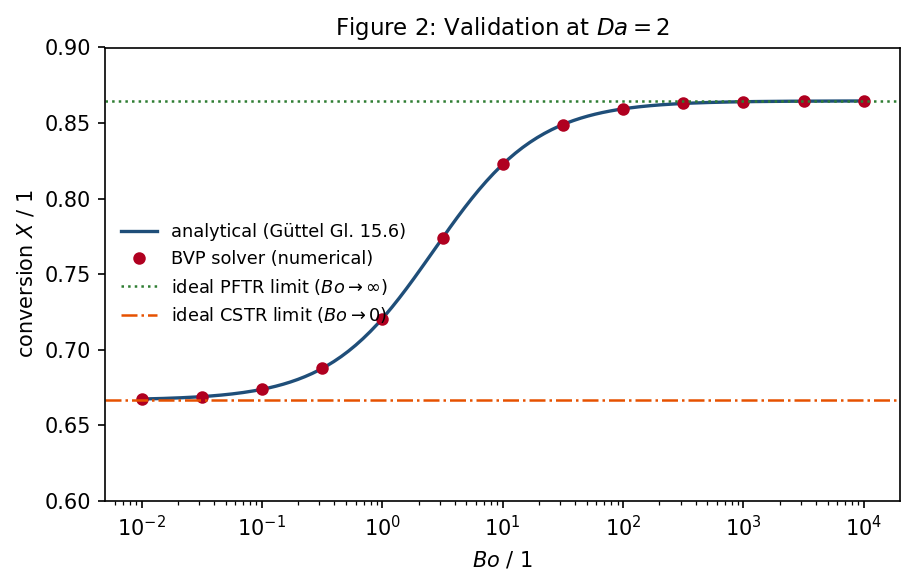

In [58]:
# ============================================================
# 3.2  PLOT — validation of the BVP against analytical limits
# ============================================================
# --- plot variables (top of cell) ---
fig_w, fig_h, fig_dpi = 6.2, 4, 150
col_ana, col_bvp, col_pfr, col_cstr = "#1f4e79", "#b00020", "#2e7d32", "#e65100"
n_line = 200

# --- smooth analytical curve + BVP markers ---
Bo_line = np.logspace(-2, 4, n_line)                                            # Gives the evaluation points for the analytical solution X_dispersion(Bo, Da) to be plotted as a smooth curve
X_line  = X_dispersion(Bo_line, Da)                                             # Calculates the analytical outlet conversion X = 1 - c_A(L)/c_A,e for each Bo_i in the Bo_line array using the analytical formula from Guettel Gl. 15.6

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=fig_dpi)
ax.plot(Bo_line, X_line, color=col_ana, lw=1.6, label="analytical (Güttel Gl. 15.6)")
ax.plot(Bo_check, X_bvp, "o", color=col_bvp, ms=5, label="BVP solver (numerical)")
ax.axhline(X_pfr(Da),  color=col_pfr,  lw=1.2, ls=":",  label=r"ideal PFTR limit ($Bo\to\infty$)")
ax.axhline(X_cstr(Da), color=col_cstr, lw=1.2, ls="-.", label=r"ideal CSTR limit ($Bo\to 0$)")

ax.set_xscale("log")
ax.set_xlabel(r"$Bo$ / 1")
ax.set_ylabel(r"conversion $X$ / 1")
ax.set_ylim(0.6, 0.9)
ax.set_title(rf"Figure 2: Validation at $Da = {Da:.0f}$", fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc="center left")
fig.tight_layout()
fig.savefig("validation_dispersion.png", dpi=250, bbox_inches="tight")

plt.show()

---
## Verification results

For the verification of our model we plotted the base case concentration profile for a Bodenstein number of 10 in comparison to an ideal PFTR and CSTR, compared our solver's conversion against the results of equation 16 and plotted these results.

<div align="center"><img src="dispersion_profile_base_case.png" width="900"></div>

The base case plot shows our model reproducing the expected behaviour. At the inlet ($z = 0$) the concentration lies below that of an ideal PFTR with no backmixing and above the constant level of an ideal CSTR with infinite backmixing. This is due to the inlet boundary condition given in equations 8 and 12: a dispersion factor greater than 0 lowers the concentration at the inlet, because fluid elements from further down the reactor — where some reaction has already lowered the concentration — are mixed back towards the beginning. This ordering only holds near the inlet, however: since backmixing lowers the outlet conversion relative to the PFTR while keeping it above the single-CSTR value, the dispersion profile crosses both reference curves along the reactor axis. At the outlet the concentration is therefore higher than that of the PFTR and shows a curvature towards $\frac{dc_{1}}{dz} = 0$, again imposed by the boundary condition from equations 8 and 12. The quantity relevant for the verification is thus the outlet conversion, which stays bracketed by the two ideal limits ($X_\mathrm{CSTR} < X_\mathrm{disp} < X_\mathrm{PFR}$). 

For the comparison of our model against the ideal edge cases, we set Bodenstein numbers of $Bo = 10^{4}$ and $Bo = 10^{-4}$ to approximate PFTR and CSTR behaviour, respectively. The base case plot above shows that our model reproduces the analytical profiles of both limits: the $Bo = 10^{4}$ solution collapses onto the ideal PFTR profile, while the $Bo = 10^{-4}$ solution flattens onto the constant ideal-CSTR level. The PFTR limit is the one relevant to the initial value problem: as $Bo \to \infty$ (i.e. $D_z \to 0$) the second-order term vanishes and the boundary value problem degenerates into the first-order IVP derived above (equations 24 and 25), which an IVP solver would integrate forward along $z$. The CSTR limit, by contrast, is not an IVP but the fully backmixed limit of the same boundary value problem, validated against the analytical single-CSTR conversion (equation 28). Neither limit can be computed directly at $Bo = \infty$ or $Bo = 0$, since $D_z = 0$ and $D_z \to \infty$ both cause a division by zero in the solver, so the finite values $10^{4}$ and $10^{-4}$ serve as close approximations. This confirms that our model behaves in a physically sound way towards both extremes of the parameter study.

Additionally, we compared the results of our model for different Bodenstein numbers with the direct analytical solution from equation 16, shown in the table below:
### Table 1: Comparison of our model with analytical results from equation 16.
<center>

| Bo        | 0.01     | 0.03     | 0.10     | 0.32     | 1.00     | 3.16     | 10.00    | 31.62    | 100.00   | 316.23   | 1000.00  | 3162.28  | 10000.00 |
|---------------|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|
| X_BVP         | 0.66740  | 0.66898  | 0.67381  | 0.68762  | 0.72061  | 0.77396  | 0.82267  | 0.84901  | 0.85941  | 0.86297  | 0.86412  | 0.86449  | 0.86461  |
| X_analytical  | 0.66740  | 0.66898  | 0.67381  | 0.68762  | 0.72061  | 0.77396  | 0.82267  | 0.84901  | 0.85941  | 0.86297  | 0.86412  | 0.86449  | 0.86461  |
| abs. diff     | 9.0e-11  | 0.0e+00  | 4.4e-16  | 3.7e-15  | 2.2e-14  | 6.6e-14  | 1.0e-13  | 1.5e-13  | 2.0e-13  | 2.2e-13  | 2.3e-13  | 2.3e-13  | 1.8e-13  |

</center>

These results show our model reproducing the analytical conversion of equation 16 across the full Bodenstein range. The maximum absolute deviation is $9.0 \times 10^{-11}$, more than two orders of magnitude below the solver tolerance of $\texttt{tol} = 10^{-8}$, so numerical and analytical results agree to within numerical precision. The lower and upper limits of the case are $X = 0.6667$ for $Bo \to 0$ and $X = 0.86466$ for $Bo \to \infty$. Our model approaches both these edge cases for very small and very large Bodenstein numbers respectively, further validating the model, as the behaviour towards the limits matches the expected ideal-reactor cases. As a graphical interpretation, the figure below shows that our model follows the analytical solution of equation 16 consistently across the whole range. The numerical solution approaches the ideal-reactor limits without overstepping these physical boundaries and reproduces the conversion trend at intermediate Bodenstein numbers.

<div align="center"><img src="validation_dispersion.png" width="900"></div>

All validation checks confirm the model, so we consider it validated for the base case from this point on. This validation is limited to a reaction order of one, however, since the analytical reference (equation 16) is only defined for first-order reactions.

---

## 3.3 Parameter variation and study 

For the parameter variation and study of the backmixing inside a PFTR, we first vary the Bodenstein number — and consequently the dispersion coefficient — to simulate different degrees of backmixing (higher values of $D_z$ correspond to stronger backmixing) and study their effect on the concentration profile along the reactor axis. We perform this variation for four different Damköhler numbers, representing different reaction rate constants and therefore different reaction rates.

After varying the parameters of the dispersion model, we compare it with the cascade model (see section 2.3) for a Damköhler number of 2 and six different Bodenstein numbers, chosen to fit the validity range of the cascade model (exact for $K \geq 50$ and applicable down to $K \geq 10$).

The discussion of the obtained results is presented compactly in section 4 ("Discussion") to keep the report readable. All calculations and plots are therefore carried out here in the sections 3.x, while the interpretation of every result is collected further below.

In [59]:
# ============================================================
# 3.3  Bo-SWEEP — concentration profiles (Guettel Abb. 15.2 style)
# ============================================================
# Fixed Da, varying Bo: the profile transitions from CSTR-like (low Bo,
# strong backmixing) to PFR-like (high Bo, weak backmixing).

Bo_sweep = np.array([0.5, 1, 3, 10, 30, 100])

# solve the BVP for each Bo and store the dimensionless profile f_A = c_A / c_A,e
n_prof   = 400
zeta     = np.linspace(0, 1, n_prof)                # dimensionless axial coordinate z/L
profiles = []                                       # storage list
print(f"{'Bo':>6} | {'f(0)':>6} | {'f(L)':>6} | {'X':>6}")
print("-" * 33)
for Bo_i in Bo_sweep:
    sol_i = solve_dispersion(Bo_i, N=400)
    f_i   = sol_i.sol(zeta * L)[0] / c_A_in        # f_A(zeta) = c_A(z) / c_A,e
    profiles.append(f_i)
    print(f"{Bo_i:>6.1f} | {f_i[0]:>6.3f} | {f_i[-1]:>6.3f} | {1 - f_i[-1]:>6.3f}")

    Bo |   f(0) |   f(L) |      X
---------------------------------
   0.5 |  0.442 |  0.302 |  0.698
   1.0 |  0.519 |  0.279 |  0.721
   3.0 |  0.687 |  0.229 |  0.771
  10.0 |  0.854 |  0.177 |  0.823
  30.0 |  0.941 |  0.152 |  0.848
 100.0 |  0.981 |  0.141 |  0.859


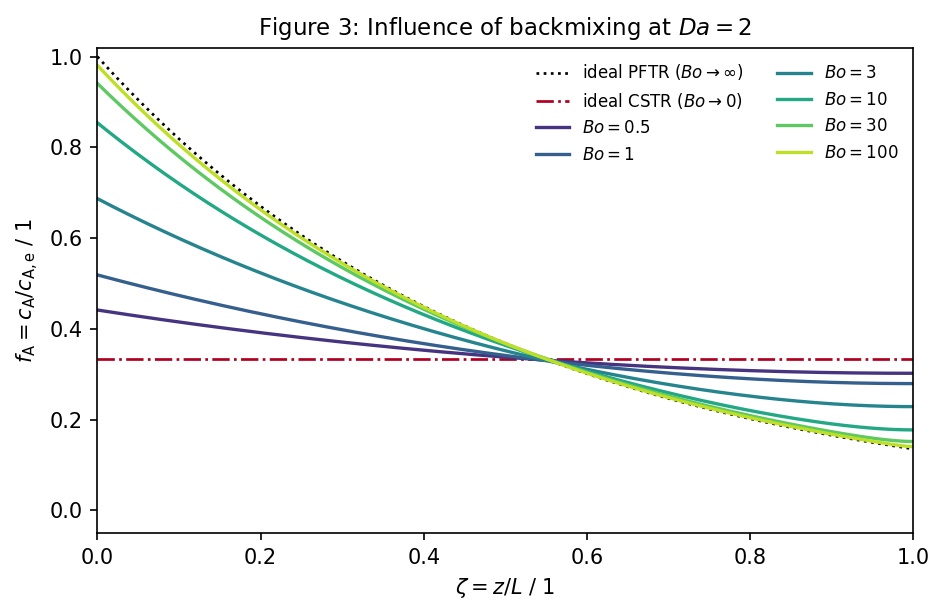

In [60]:
# ============================================================
# 3.3  PLOT — Bo-sweep concentration profiles
# ============================================================
# --- plot variables (top of cell) ---
fig_w, fig_h, fig_dpi = 6.4, 4.2, 150
cmap     = plt.cm.viridis
col_pfr  = "#000000"
col_cstr = "#b00020"
lw_prof  = 1.6
n_cases  = len(Bo_sweep)

# colour-grade the BVP profiles by their position in the sweep (low -> high Bo)
colors = cmap(np.linspace(0.15, 0.9, n_cases))

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=fig_dpi)

# analytical bounding cases (theoretical limits)
ax.plot(zeta, np.exp(-Da * zeta), color=col_pfr, lw=1.3, ls=":",
        label=r"ideal PFTR ($Bo\to\infty$)")
ax.axhline(1 / (1 + Da), color=col_cstr, lw=1.3, ls="-.",
           label=r"ideal CSTR ($Bo\to 0$)")

# BVP profiles for increasing Bo
for f_i, Bo_i, c in zip(profiles, Bo_sweep, colors):
    ax.plot(zeta, f_i, color=c, lw=lw_prof, label=rf"$Bo = {Bo_i:g}$")

ax.set_xlabel(r"$\zeta = z/L$ / 1")
ax.set_ylabel(r"$f_\mathrm{A} = c_\mathrm{A}/c_\mathrm{A,e}$ / 1")
ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.02)
ax.set_title(rf"Figure 3: Influence of backmixing at $Da = {Da:.0f}$", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="upper right", ncol=2)
fig.tight_layout()
fig.savefig("Influence_of_backmixing_at_Da_2.png", dpi=fig_dpi, bbox_inches="tight")
plt.show()

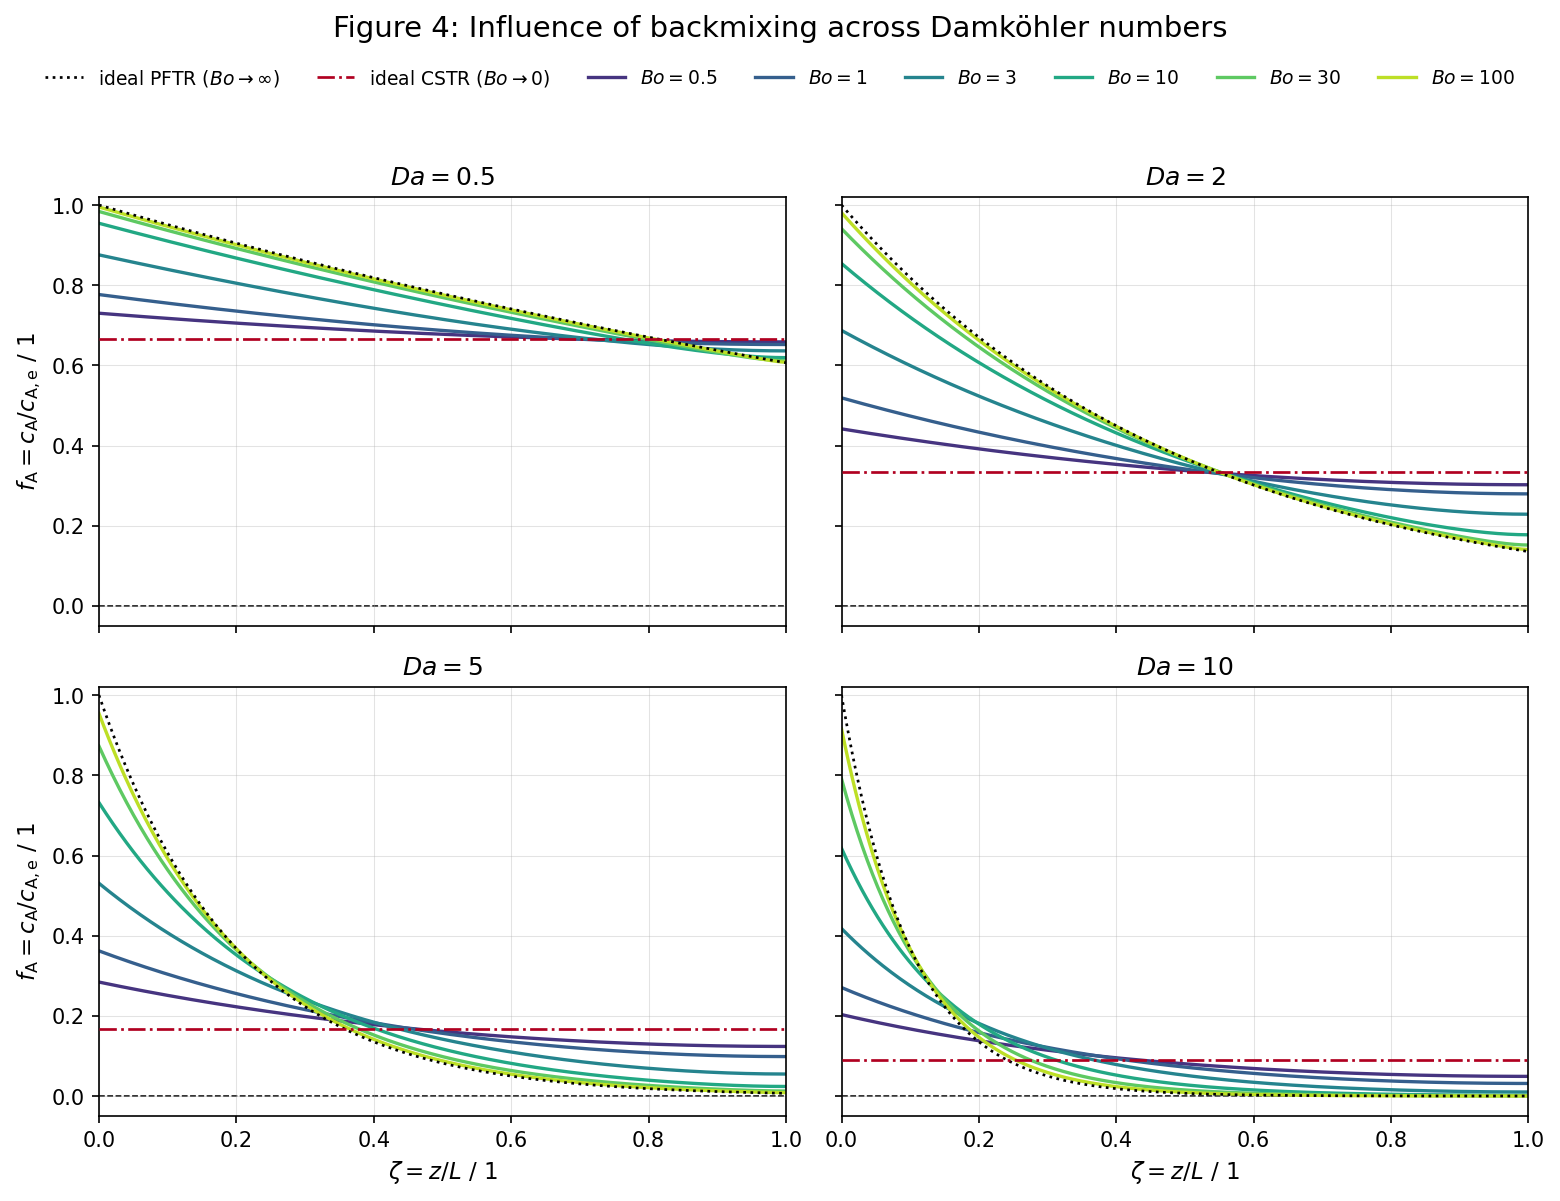

In [61]:
# ============================================================
# 3.3  Da-SWEEP — Bo profiles across four Damköhler numbers
# ============================================================
# Same Bo sweep as in the single-Da plot above, now repeated for four Da.
# Each panel shows the transition from CSTR-like (low Bo) to PFR-like (high Bo)
# together with the two ideal limits, which shift with Da.
# --- plot variables (top of cell) ---
fig_w, fig_h, fig_dpi = 10.5, 8.0, 150
n_rows, n_cols        = 2, 2
Da_values             = [0.5, 2, 5, 10]                 # reaction speed: slow -> very fast
Bo_sweep              = np.array([0.5, 1, 3, 10, 30, 100])   # same sweep as the single-Da plot
n_prof                = 400
zeta                  = np.linspace(0, 1, n_prof)       # dimensionless axial coordinate z/L
cmap                  = plt.cm.viridis
col_pfr, col_cstr     = "#000000", "#b00020"           # ideal-limit line colours (match 3.3 single-Da plot)
lw_prof, lw_lim       = 1.6, 1.3
grid_lw, grid_alpha   = 0.5, 0.35
n_cases               = len(Bo_sweep)
colors                = cmap(np.linspace(0.15, 0.9, n_cases))   # low -> high Bo

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), dpi=fig_dpi,
                         sharex=True, sharey=True)
axes_flat = axes.flatten()

for ax, Da_i in zip(axes_flat, Da_values):
    # ideal bounding cases (shift with Da)
    ax.plot(zeta, np.exp(-Da_i * zeta), color=col_pfr, lw=lw_lim, ls=":", zorder=3,
            label=r"ideal PFTR ($Bo\to\infty$)")
    ax.axhline(1 / (1 + Da_i), color=col_cstr, lw=lw_lim, ls="-.", zorder=3,
               label=r"ideal CSTR ($Bo\to 0$)")
    ax.axhline(0, color="k", lw=0.75, ls="--", zorder=1)   # zero line for visual reference
    # BVP profiles for increasing Bo at this Da
    for Bo_i, c in zip(Bo_sweep, colors):
        f_i = solve_dispersion(Bo_i, Da=Da_i).sol(zeta * L)[0] / c_A_in
        ax.plot(zeta, f_i, color=c, lw=lw_prof, label=rf"$Bo = {Bo_i:g}$")
    ax.set_title(rf"$Da = {Da_i:g}$", fontsize=12)
    ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1.02)
    ax.grid(True, lw=grid_lw, alpha=grid_alpha)

# axis labels only on outer panels
for a in axes[-1, :]: a.set_xlabel(r"$\zeta = z/L$ / 1", fontsize=11)
for a in axes[:, 0]:  a.set_ylabel(r"$f_\mathrm{A} = c_\mathrm{A}/c_\mathrm{A,e}$ / 1", fontsize=11)

# single shared legend (Bo values identical across panels)
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.965),
           ncol=8, fontsize=9, frameon=False)
fig.suptitle("Figure 4: Influence of backmixing across Damköhler numbers", fontsize=14, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("Influence_of_backmixing_Da_sweep.png", dpi=fig_dpi, bbox_inches="tight")
plt.show()

   Da |  X_CSTR |   X_PFR |   span
----------------------------------
  0.5 |   0.333 |   0.393 |  0.060
    2 |   0.667 |   0.865 |  0.198
    5 |   0.833 |   0.993 |  0.160
   10 |   0.909 |   1.000 |  0.091


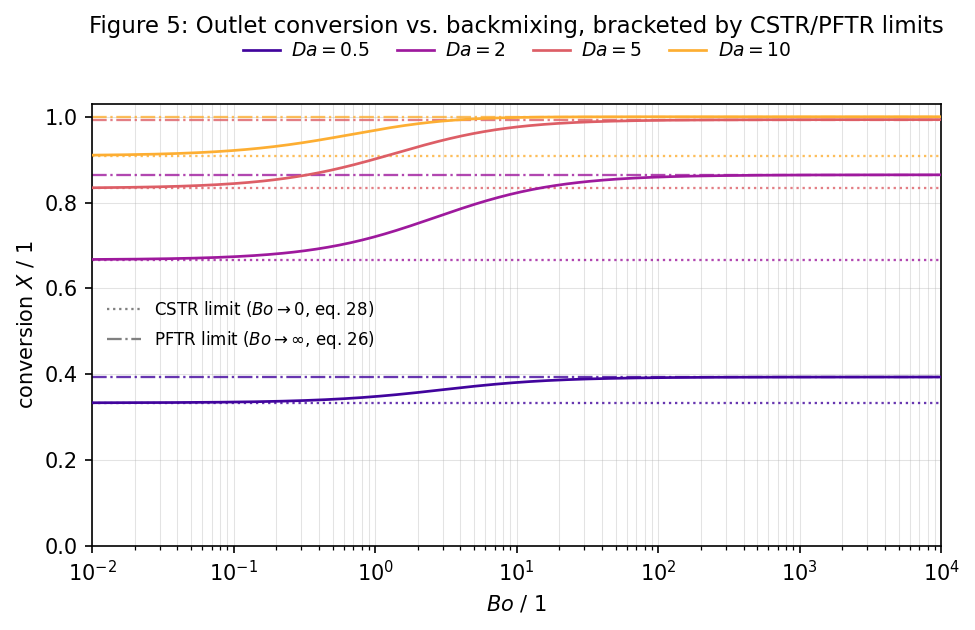

In [62]:
# ============================================================
# 3.3  Da-SWEEP -- outlet conversion vs. Bodenstein number
# ============================================================
# Shows the analytical outlet conversion X(Bo) (Guettel Gl. 15.6, p. 209)
# for four Damkoehler numbers, each bracketed by its own ideal-reactor
# limits: the CSTR limit (Bo -> 0, eq. 28) and the PFTR limit (Bo -> inf,
# eq. 26). Both limit functions (X_cstr, X_pfr) are reused from the
# analytical-reference cell -- no redefinition needed here.
from matplotlib.lines import Line2D

# --- plot variables (top of cell) ---
fig_w, fig_h, fig_dpi   = 6.6, 4.3, 150
Da_values               = [0.5, 2, 5, 10]
n_line                  = 300
Bo_line                 = np.logspace(-2, 4, n_line)         # wide range -> both plateaus visible
cmap_da                 = plt.cm.plasma
colors_da               = cmap_da(np.linspace(0.1, 0.82, len(Da_values)))
lw_curve                = 1.3                                 # linewidth of the X(Bo) curves
lw_limit                = 1.1                                 # linewidth of the CSTR/PFTR limit lines
ls_cstr, ls_pfr         = ":", "-."                            # linestyle: dotted = CSTR, dash-dot = PFTR
limit_alpha             = 0.8
legend_fontsize         = 9
legend_ncol             = len(Da_values)
legend_bbox_da          = (0.5, 1.18)                          # Da legend: flat, above the axes
xlim, ylim              = (1e-2, 1e4), (0.0, 1.03)
grid_lw, grid_alpha     = 0.5, 0.35

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=fig_dpi)

print(f"{'Da':>5} | {'X_CSTR':>7} | {'X_PFR':>7} | {'span':>6}")
print("-" * 34)
for Da_i, c in zip(Da_values, colors_da):
    ax.plot(Bo_line, X_dispersion(Bo_line, Da_i), color=c, lw=lw_curve,
             zorder=3, label=rf"$Da = {Da_i:g}$")
    ax.axhline(X_cstr(Da_i), color=c, lw=lw_limit, ls=ls_cstr, alpha=limit_alpha, zorder=2)
    ax.axhline(X_pfr(Da_i),  color=c, lw=lw_limit, ls=ls_pfr,  alpha=limit_alpha, zorder=2)
    print(f"{Da_i:>5g} | {X_cstr(Da_i):>7.3f} | {X_pfr(Da_i):>7.3f} | {X_pfr(Da_i)-X_cstr(Da_i):>6.3f}")

ax.set_xscale("log")
ax.set_xlabel(r"$Bo$ / 1")
ax.set_ylabel(r"conversion $X$ / 1")
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.grid(True, which="both", lw=grid_lw, alpha=grid_alpha)
ax.set_title("Figure 5: Outlet conversion vs. backmixing, bracketed by CSTR/PFTR limits", fontsize=11, pad=34)

# legend 1: Da -> color, flat/horizontal, above the axes
legend_da = ax.legend(frameon=False, fontsize=legend_fontsize, loc="upper center",
                       bbox_to_anchor=legend_bbox_da, ncol=legend_ncol,
                       columnspacing=1.4, handletextpad=0.6)
ax.add_artist(legend_da)

# legend 2: linestyle -> meaning (CSTR/PFTR limit), neutral gray, inside the plot
style_handles = [
    Line2D([0], [0], color="gray", lw=lw_limit, ls=ls_cstr, label=r"CSTR limit ($Bo\to 0$, eq. 28)"),
    Line2D([0], [0], color="gray", lw=lw_limit, ls=ls_pfr,  label=r"PFTR limit ($Bo\to\infty$, eq. 26)"),
]
ax.legend(handles=style_handles, frameon=False, fontsize=legend_fontsize - 1, loc="center left")

fig.tight_layout()
fig.savefig("conversion_vs_Bo_Da_sweep.png", dpi=1000, bbox_inches="tight")
plt.show()

## 3.4 Investigating different reaction orders

In [63]:
# ============================================================
# 3.4  DISPERSION MODEL FOR ARBITRARY REACTION ORDER n
# ============================================================
# Steady-state dispersion model with an n-th order reaction A -> B, r = k*c_A^n.
# Non-dimensionalising (f = c_A/c_A,e, zeta = z/L) gives
#   (1/Bo) f'' - f' - Da_n * f^n = 0      (generalises Guettel Gl. 15.3a, p. 209:
#   the reaction term Da_I/r_1,e * sum(nu_ij r_j) becomes -Da_n f^n for order n),
# with the order-n Damkoehler number
#   Da_n = k * c_A,e^(n-1) * tau   ->   k = Da_n / (c_A,e^(n-1) * tau).
# For n = 1 this reduces to Da = k*tau, so the model is backward compatible.
# The Danckwerts boundary conditions (Guettel Gl. 15.2b/c, p. 208-209) are unchanged.
# The closed-form solution (Guettel Gl. 15.4/15.6) exists ONLY for n = 1; for n != 1
# the model is validated against the ideal CSTR and PFTR limits instead.

from scipy.optimize import brentq

def rate_power(c, n):
    "Sign-preserving c^n; equals the physical c^n for c >= 0, robust for non-integer n."
    return np.sign(c) * np.abs(c)**n

def dispersion_rhs_n(z, y, k, D, u, n):
    "RHS of the n-th order dispersion-model ODE system (D*c'' - u*c' - k*c^n = 0)."
    dc_A  = y[1]
    d2c_A = (u / D) * y[1] + (k / D) * rate_power(y[0], n)
    return np.vstack((dc_A, d2c_A))

def dispersion_bc_n(ya, yb, D, u, c_in):
    "Residuals of the two Danckwerts boundary conditions (identical to the n=1 case)."
    return np.array([ya[0] - (D / u) * ya[1] - c_in, yb[1]])

def f_pftr_n(zeta, Da, n):
    "Ideal PFTR profile f_A(zeta) for order n (Bo -> inf)."
    if abs(n - 1) < 1e-12:
        return np.exp(-Da * zeta)                              # n = 1 limit
    return (1 + (n - 1) * Da * zeta)**(1 / (1 - n))

def X_pftr_n(Da, n):
    "Ideal PFTR outlet conversion for order n."
    return 1 - f_pftr_n(1.0, Da, n)

def X_cstr_n(Da, n):
    "Ideal single-CSTR outlet conversion for order n: solve 1 - f - Da*f^n = 0 for f in (0,1]."
    f_out = brentq(lambda f: 1 - f - Da * f**n, 1e-12, 1.0)
    return 1 - f_out

def solve_dispersion_n(Bo, Da, n, N=600):
    "Solve the n-th order dispersion-model BVP for given Bo, Da, n; return the solution object."
    k_loc = Da / (c_A_in**(n - 1) * tau)                       # k from Da_n = k*c_A,e^(n-1)*tau
    D     = u * L / Bo                                         # axial dispersion coefficient
    z     = np.linspace(0, L, N)
    f_g   = f_pftr_n(z / L, Da, n)                             # PFTR profile as initial guess
    yg    = np.zeros((2, N))
    yg[0] = c_A_in * f_g
    yg[1] = np.gradient(c_A_in * f_g, z)                       # matching derivative guess
    fun   = partial(dispersion_rhs_n, k=k_loc, D=D, u=u, n=n)
    bc    = partial(dispersion_bc_n,  D=D, u=u, c_in=c_A_in)
    return solve_bvp(fun, bc, z, yg, tol=1e-8, max_nodes=300000)

# --- backward-compatibility check: n=1 must reproduce the existing solver ---
z_chk = np.linspace(0, L, 200)
_diff = np.max(np.abs(solve_dispersion_n(10, Da, 1).sol(z_chk)[0] - solve_dispersion(10).sol(z_chk)[0]))
print(f"n=1 consistency vs solve_dispersion: max abs. diff = {_diff:.2e}")

n=1 consistency vs solve_dispersion: max abs. diff = 8.70e-11


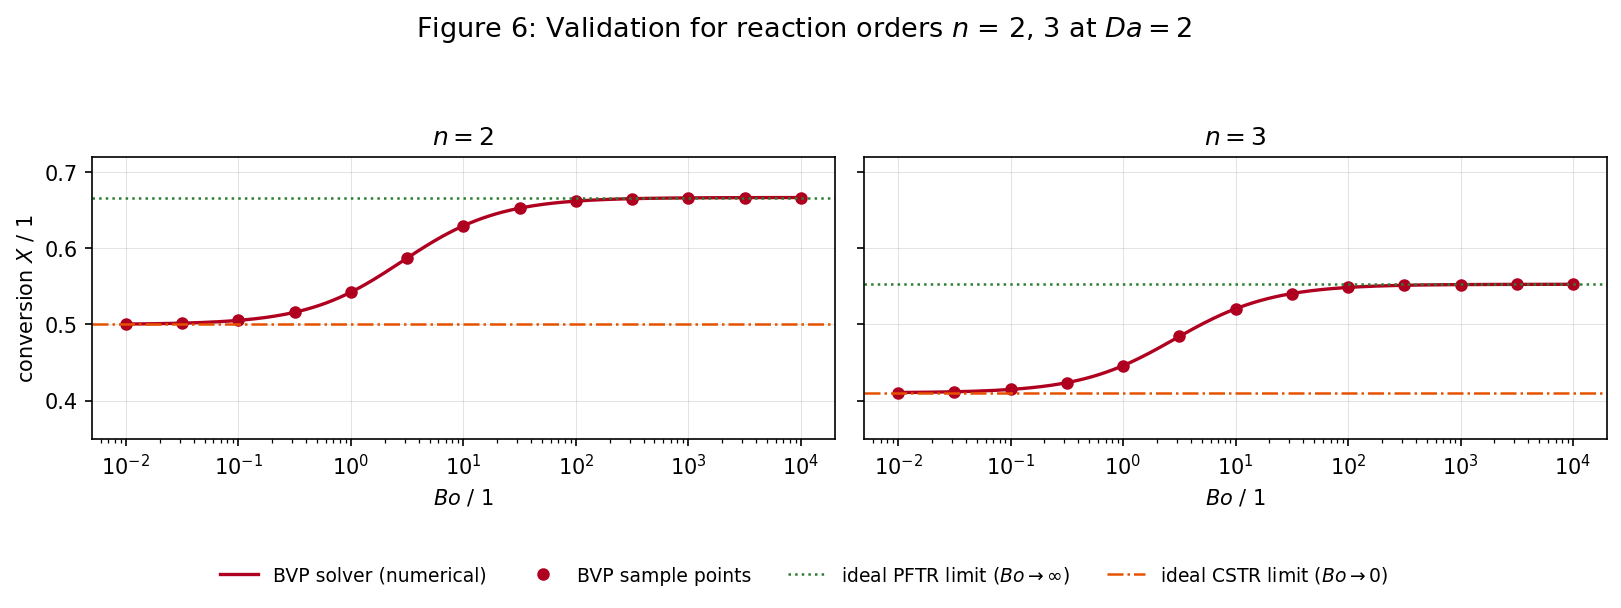

In [64]:
# ============================================================
# 3.4  VALIDATION — BVP vs ideal CSTR/PFTR limits (order n != 1)
# ============================================================
# No closed-form dispersion solution exists for n != 1 (Guettel Gl. 15.6 holds
# only for n = 1). The BVP is therefore validated against its two analytical
# bounding cases: X -> X_CSTR (Bo -> 0) and X -> X_PFTR (Bo -> inf).
# --- plot variables (top of cell) ---
fig_w, fig_h, fig_dpi      = 11, 4, 150
n_orders                   = [2, 3]                        # reaction orders to validate
Da_val                     = 2.0                           # fixed Damkoehler number
Bo_check                   = np.logspace(-2, 4, 13)        # discrete markers: CSTR-like ... PFR-like
Bo_line                    = np.logspace(-2, 4, 200)       # smooth BVP transition curve
col_bvp, col_pfr, col_cstr = "#b00020", "#2e7d32", "#e65100"
lw_curve, lw_lim, ms_bvp   = 1.6, 1.2, 5
y_lo, y_hi                 = 0.35, 0.72

fig, axes = plt.subplots(1, len(n_orders), figsize=(fig_w, fig_h), dpi=fig_dpi, sharey=True)

for ax, n in zip(axes, n_orders):
    X_curve = np.array([1 - solve_dispersion_n(Bo, Da_val, n).sol(L)[0] / c_A_in for Bo in Bo_line])
    X_pts   = np.array([1 - solve_dispersion_n(Bo, Da_val, n).sol(L)[0] / c_A_in for Bo in Bo_check])
    ax.plot(Bo_line,  X_curve, color=col_bvp, lw=lw_curve, label="BVP solver (numerical)")
    ax.plot(Bo_check, X_pts, "o", color=col_bvp, ms=ms_bvp, label="BVP sample points")
    ax.axhline(X_pftr_n(Da_val, n), color=col_pfr,  lw=lw_lim, ls=":",  label=r"ideal PFTR limit ($Bo\to\infty$)")
    ax.axhline(X_cstr_n(Da_val, n), color=col_cstr, lw=lw_lim, ls="-.", label=r"ideal CSTR limit ($Bo\to 0$)")
    ax.set_xscale("log")
    ax.set_xlabel(r"$Bo$ / 1")
    ax.set_ylim(y_lo, y_hi)
    ax.set_title(rf"$n = {n}$", fontsize=12)
    ax.grid(True, lw=0.5, alpha=0.35)

axes[0].set_ylabel(r"conversion $X$ / 1")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.0),
           ncol=4, fontsize=9, frameon=False)
fig.suptitle(rf"Figure 6: Validation for reaction orders $n$ = 2, 3 at $Da = {Da_val:.0f}$", fontsize=13, y=0.98)
fig.tight_layout(rect=[0, 0.12, 1, 0.92])
fig.savefig("validation_dispersion_order_n.png", dpi=fig_dpi, bbox_inches="tight")
plt.show()

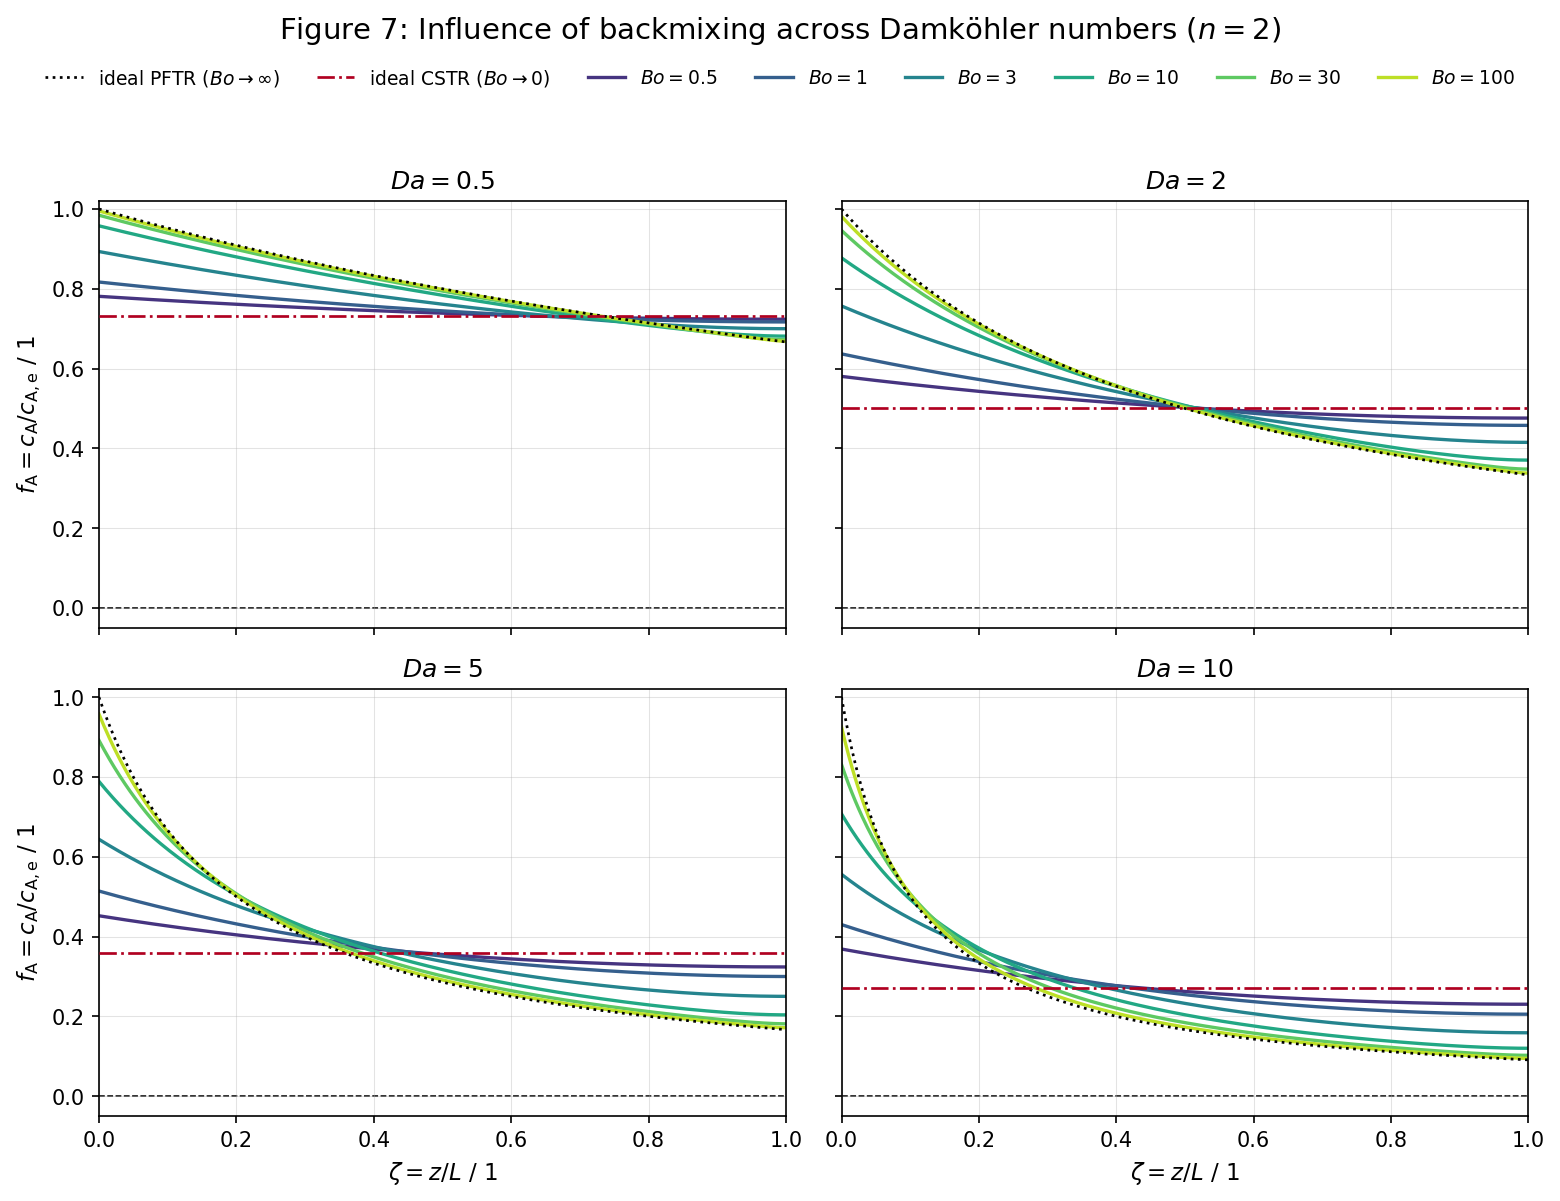

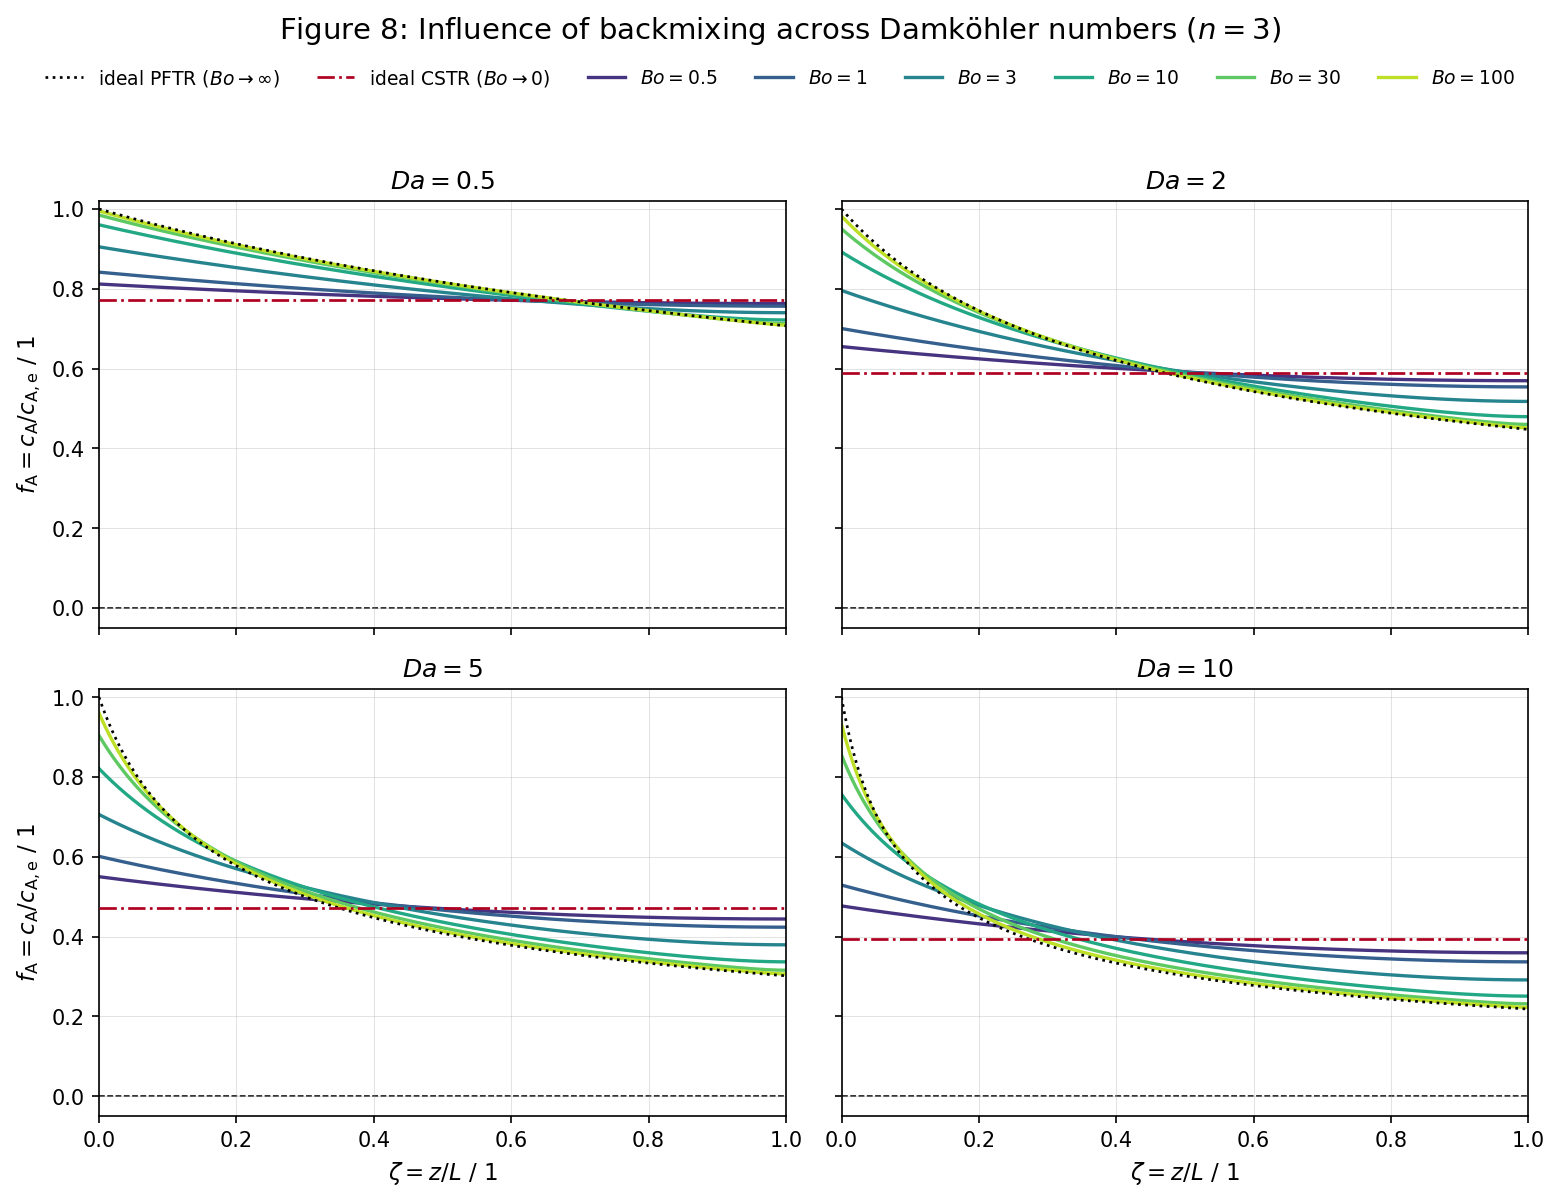

In [65]:
# ============================================================
# 3.4  Da-SWEEP — Bo profiles across four Damköhler numbers, order n
# ============================================================
# Same layout as Figure 4 (n = 1), generalised to reaction order n.
# Ideal limits shift with both Da and n:
#   PFTR profile  f(zeta) = [1 + (n-1) Da zeta]^(1/(1-n))   (Bo -> inf)
#   CSTR level    f solves 1 - f - Da f^n = 0               (Bo -> 0)
# --- plot variables (top of cell) ---
fig_w, fig_h, fig_dpi = 10.5, 8.0, 150
n_rows, n_cols        = 2, 2
Da_values             = [0.5, 2, 5, 10]                    # reaction speed: slow -> very fast
Bo_sweep              = np.array([0.5, 1, 3, 10, 30, 100]) # same sweep as the n=1 plot
n_prof                = 400
zeta                  = np.linspace(0, 1, n_prof)          # dimensionless axial coordinate z/L
cmap                  = plt.cm.viridis
col_pfr, col_cstr     = "#000000", "#b00020"              # ideal-limit line colours (match Figure 4)
lw_prof, lw_lim       = 1.6, 1.3
grid_lw, grid_alpha   = 0.5, 0.35
n_cases               = len(Bo_sweep)
colors                = cmap(np.linspace(0.15, 0.9, n_cases))   # low -> high Bo

def plot_da_sweep_order(n, fig_no, fname):
    "2x2 Da-sweep of BVP profiles for reaction order n, with ideal CSTR/PFTR limits."
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), dpi=fig_dpi,
                             sharex=True, sharey=True)
    axes_flat = axes.flatten()
    for ax, Da_i in zip(axes_flat, Da_values):
        # ideal bounding cases (shift with Da and n)
        ax.plot(zeta, f_pftr_n(zeta, Da_i, n), color=col_pfr, lw=lw_lim, ls=":", zorder=3,
                label=r"ideal PFTR ($Bo\to\infty$)")
        ax.axhline(1 - X_cstr_n(Da_i, n), color=col_cstr, lw=lw_lim, ls="-.", zorder=3,
                   label=r"ideal CSTR ($Bo\to 0$)")
        ax.axhline(0, color="k", lw=0.75, ls="--", zorder=1)   # zero line for visual reference
        # BVP profiles for increasing Bo at this Da
        for Bo_i, c in zip(Bo_sweep, colors):
            f_i = solve_dispersion_n(Bo_i, Da_i, n).sol(zeta * L)[0] / c_A_in
            ax.plot(zeta, f_i, color=c, lw=lw_prof, label=rf"$Bo = {Bo_i:g}$")
        ax.set_title(rf"$Da = {Da_i:g}$", fontsize=12)
        ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1.02)
        ax.grid(True, lw=grid_lw, alpha=grid_alpha)

    for a in axes[-1, :]: a.set_xlabel(r"$\zeta = z/L$ / 1", fontsize=11)
    for a in axes[:, 0]:  a.set_ylabel(r"$f_\mathrm{A} = c_\mathrm{A}/c_\mathrm{A,e}$ / 1", fontsize=11)

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.965),
               ncol=8, fontsize=9, frameon=False)
    fig.suptitle(rf"Figure {fig_no}: Influence of backmixing across Damköhler numbers ($n = {n}$)",
                 fontsize=14, y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(fname, dpi=fig_dpi, bbox_inches="tight")
    plt.show()

# --- generate the two requested plots (orders 2 and 3) ---
plot_da_sweep_order(2, 7, "Da_sweep_order_2.png")
plot_da_sweep_order(3, 8, "Da_sweep_order_3.png")

## 3.5 Cascade model

In [66]:
# ============================================================
# 3.5  CSTR CASCADE MODEL — comparison with dispersion model
# ============================================================
# Cascade of K equal-sized ideal CSTRs, isothermal, 1st-order reaction.
# Closed-form conversion (Guettel Gl. 15.14, p. 213), derived from the
# single-CSTR balance (Gl. 12.1a) applied recursively over K vessels.

def X_cascade(K, Da):
    "Conversion of a cascade of K equal ideal CSTRs (Guettel Gl. 15.14, p. 213)."
    return 1 - 1 / (1 + Da / K)**K

# --- selected Bo values: two from the Task-2 sweep (30, 100) + four new ---
Bo_cascade = np.array([30, 50, 75, 100, 200, 500])
K_cascade  = Bo_cascade / 2          # Guettel Gl. 15.13, p. 213: K = Bo/2

# --- validity classification of Gl. 15.13 (Guettel, p. 213) ---
def K_validity(K):
    "Validity range of K = Bo/2 (Guettel, p. 213): exact for K>=50, approx. for 10<=K<50."
    if K >= 50:
        return "exact (K >= 50)"
    elif K >= 10:
        return "approx. (10 <= K < 50)"
    else:
        return "not valid (K < 10)"

# --- comparison: cascade vs. dispersion model at matching Bo ---
X_casc = X_cascade(K_cascade, Da)
X_disp = np.array([1 - solve_dispersion(Bo_i).sol(L)[0] / c_A_in for Bo_i in Bo_cascade])

print(f"{'Bo':>6} | {'K=Bo/2':>7} | {'validity':>22} | {'X_cascade':>10} | {'X_dispersion':>12} | {'abs. diff':>10}")
print("-" * 82)
for Bo_i, K_i, Xc, Xd in zip(Bo_cascade, K_cascade, X_casc, X_disp):
    print(f"{Bo_i:>6.0f} | {K_i:>7.1f} | {K_validity(K_i):>22} | {Xc:>10.5f} | {Xd:>12.5f} | {abs(Xc-Xd):>10.2e}")

    Bo |  K=Bo/2 |               validity |  X_cascade | X_dispersion |  abs. diff
----------------------------------------------------------------------------------
    30 |    15.0 | approx. (10 <= K < 50) |    0.84702 |      0.84824 |   1.22e-03
    50 |    25.0 | approx. (10 <= K < 50) |    0.85398 |      0.85444 |   4.63e-04
    75 |    37.5 | approx. (10 <= K < 50) |    0.85751 |      0.85772 |   2.12e-04
   100 |    50.0 |        exact (K >= 50) |    0.85929 |      0.85941 |   1.21e-04
   200 |   100.0 |        exact (K >= 50) |    0.86197 |      0.86200 |   3.09e-05
   500 |   250.0 |        exact (K >= 50) |    0.86358 |      0.86359 |   5.01e-06


In [67]:
# ============================================================
# 3.5  CSTR CASCADE — stepwise concentration profiles
# ============================================================
# Note: K = Bo/2 (Guettel Gl. 15.13) is generally non-integer (e.g. Bo=75 -> K=37.5).
# For an actual staircase profile we need a whole number of physical vessels,
# so K is rounded to the nearest integer here. This rounding only affects the
# visualization, NOT the U(Da,K) values reported in the table above (Gl. 15.14
# is evaluated there with the exact, continuous K).

K_int_cascade = np.round(K_cascade).astype(int)   # rounded vessel count per Bo case

def cascade_profile(K, Da):
    "Stepwise f_A = c_A/c_A,e at vessel boundaries (0=inlet, K=outlet) for K equal CSTRs."
    k_idx = np.arange(0, K + 1)
    f_A   = 1.0 / (1 + Da / K)**k_idx               # Guettel Gl. 15.14 building block, per vessel
    zeta  = k_idx / K                               # dimensionless position (equal vessel volumes)
    return zeta, f_A

print(f"{'Bo':>6} | {'K (exact)':>10} | {'K (rounded)':>12}")
print("-" * 34)
for Bo_i, Ke, Ki in zip(Bo_cascade, K_cascade, K_int_cascade):
    print(f"{Bo_i:>6.0f} | {Ke:>10.1f} | {Ki:>12d}")

    Bo |  K (exact) |  K (rounded)
----------------------------------
    30 |       15.0 |           15
    50 |       25.0 |           25
    75 |       37.5 |           38
   100 |       50.0 |           50
   200 |      100.0 |          100
   500 |      250.0 |          250


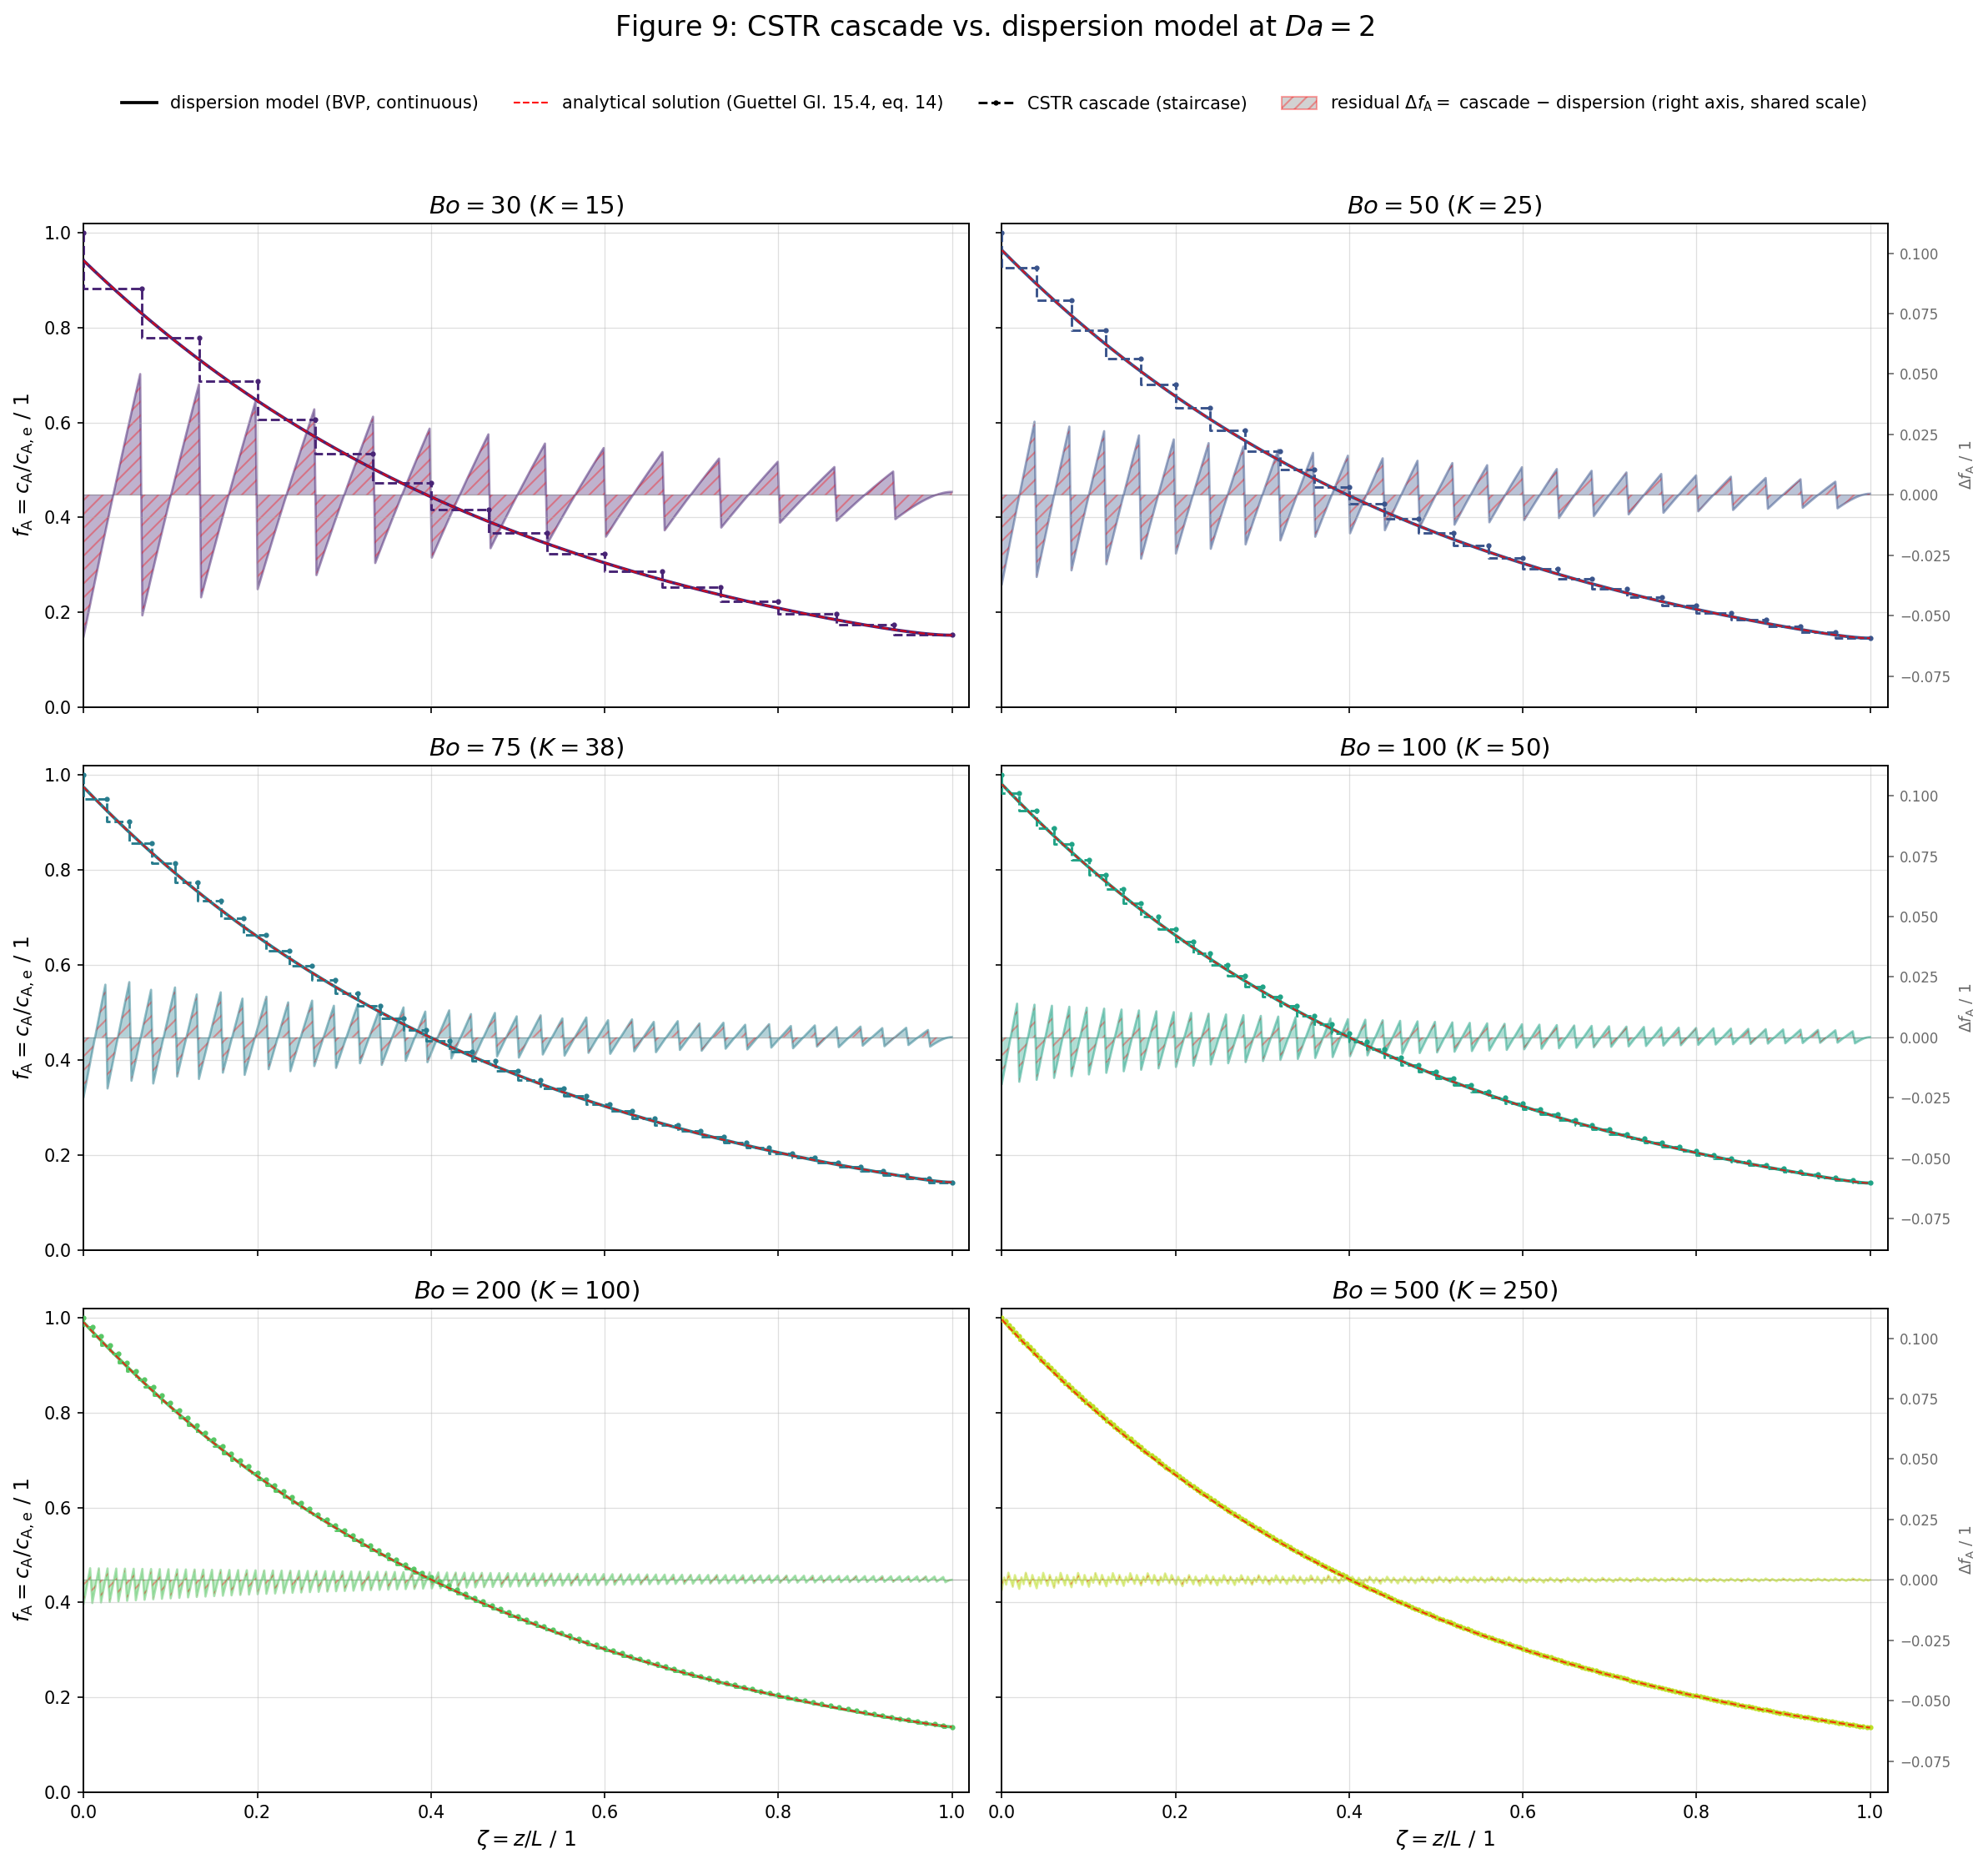

In [68]:
# ============================================================
# 3.5  PLOT — CSTR cascade (staircase) vs. dispersion model
#             + analytical dispersion profile (eq. 14, Guettel Gl. 15.4, p. 209)
#             + hatched residual area (shared scale across all Bo cases)
#             all axis labels/ticks only on outer subplots
#             (x: bottom row, y1: left col, y2: right col)
# ============================================================
# NOTE on the staircase (where="pre"):
# An ideal CSTR is perfectly mixed, so the concentration is uniform across the
# whole vessel and equal to its OUTLET value. Cell i (spatial range
# (zeta_{i-1}, zeta_i]) must therefore be drawn at f_A,i, and the profile steps
# DOWN at each vessel inlet. Using where="post" would wrongly hold f_0 = 1 over
# the first vessel. The same convention is used for the residual evaluation below.
# ============================================================
# --- plot variables (top of cell) ---
fig_w, fig_h, fig_dpi     = 16, 15, 150
n_rows, n_cols            = 3, 2
cmap                      = plt.cm.viridis
n_cases                   = len(Bo_cascade)
colors                    = cmap(np.linspace(0.1, 0.9, n_cases))
lw_disp, lw_casc, ms_casc, lw_diff = 1.8, 1.4, 2, 1.3
n_eval                    = 400
zeta_eval                 = np.linspace(0, 1, n_eval)
grid_lw, grid_alpha       = 0.6, 0.4
fill_alpha                = 0.35
hatch_pattern, hatch_color = "///", "red"

# --- analytical reference line (eq. 14 / Guettel Gl. 15.4): thin, black, dashed ---
lw_ana, ls_ana, color_ana, z_ana, alpha_ana = 1.0, "--", "red", 6, 0.75

# --- legend layout (pulled up here per plot-variable convention) ---
n_legend_cols, legend_fontsize    = 4, 10

def step_eval_pre(zeta_query, zeta_nodes, f_nodes):
    "Evaluate the 'pre'-style step function used by ax.step(where='pre') at arbitrary zeta."
    "Each spatial cell (zeta_{i-1}, zeta_i] carries the OUTLET value f_nodes[i] of that vessel;"
    "clip lower bound 1 keeps zeta=0 on f_1 (vessel-1 outlet), not on the pure feed value f_0=1."
    idx = np.searchsorted(zeta_nodes, zeta_query, side="left")
    idx = np.clip(idx, 1, len(f_nodes) - 1)
    return f_nodes[idx]

def f_A_analytical(Bo, Da, zeta):
    "Analytical dispersion profile f_A(zeta) for a 1st-order reaction (eq. 14 / Guettel Gl. 15.4, p. 209)."
    "Numerically stabilized: numerator and denominator are divided by exp[Bo(1+b)/2],"
    "so every exponent is <= 0 and the expression does not overflow for large Bo."
    b   = np.sqrt(1 + 4 * Da / Bo)                                        # eq. 15 / Guettel Gl. 15.5, p. 209
    num = ( 2 * (1 + b) * np.exp(0.5 * Bo * (1 - b) * zeta)
          - 2 * (1 - b) * np.exp(0.5 * Bo * (1 - b) - 0.5 * Bo * (1 + b) * (1 - zeta)) )
    den = (1 + b)**2 - (1 - b)**2 * np.exp(-Bo * b)
    return num / den

# --- pre-compute residuals for ALL cases first, to fix one shared secondary-axis scale ---
diff_lines = {}
for Bo_i, K_i in zip(Bo_cascade, K_int_cascade):
    sol_i       = solve_dispersion(Bo_i)
    f_disp      = sol_i.sol(zeta_eval * L)[0] / c_A_in
    zeta_c, f_c = cascade_profile(K_i, Da)
    f_step      = step_eval_pre(zeta_eval, zeta_c, f_c)       # cascade cell = outlet value (pre)
    diff_lines[Bo_i] = f_step - f_disp

all_diffs  = np.concatenate(list(diff_lines.values()))
diff_ylim  = (min(0, all_diffs.min()) * 1.5, all_diffs.max() * 2.25)   # SAME for all 6 panels

fig, axes  = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), dpi=fig_dpi,
                           sharex=True, sharey=True)
axes_flat  = axes.flatten()

for idx, (ax, Bo_i, K_i, c) in enumerate(zip(axes_flat, Bo_cascade, K_int_cascade, colors)):
    is_right_col = (idx % n_cols == n_cols - 1)     # True only for column 2 (rightmost)

    # dispersion model: smooth profile, solid line
    sol_i  = solve_dispersion(Bo_i)
    f_disp = sol_i.sol(zeta_eval * L)[0] / c_A_in
    ax.plot(zeta_eval, f_disp, color=c, lw=lw_disp, ls="-", zorder=4)

    # analytical dispersion solution (eq. 14): thin black dashed reference on top of the BVP profile
    f_ana = f_A_analytical(Bo_i, Da, zeta_eval)
    ax.plot(zeta_eval, f_ana, color=color_ana, lw=lw_ana, ls=ls_ana, zorder=z_ana, alpha=alpha_ana)

    # CSTR cascade: staircase profile, dashed + markers
    # where="pre" -> each vessel is drawn at its OUTLET concentration, stepping DOWN at the inlet
    zeta_c, f_c = cascade_profile(K_i, Da)
    ax.step(zeta_c, f_c, where="pre", color=c, lw=lw_casc, ls="--", zorder=3)
    ax.plot(zeta_c, f_c, "o", color=c, ms=ms_casc, zorder=5)

    # residual: cascade staircase minus dispersion, filled + red-hatched, shared scale
    diff_line = diff_lines[Bo_i]
    ax2 = ax.twinx()
    ax2.plot(zeta_eval, diff_line, color=c, lw=lw_diff, zorder=1, alpha=0.5)
    ax2.fill_between(zeta_eval, 0, diff_line, facecolor=c, alpha=fill_alpha,
                      hatch=hatch_pattern, edgecolor=hatch_color, linewidth=0.0, zorder=1)
    ax2.axhline(0, color="gray", lw=0.6, alpha=0.6, zorder=0)
    ax2.set_ylim(diff_ylim)                           # identical range on every subplot

    if is_right_col:                                   # axis title + tick numbers: outer (right) column only
        ax2.set_ylabel(r"$\Delta f_\mathrm{A}$ / 1", fontsize=9, color="dimgray")
        ax2.tick_params(axis="y", labelsize=8, colors="dimgray")
    else:                                               # inner plots: no numbers, no tick marks
        ax2.tick_params(axis="y", labelright=False, length=0)

    ax.set_zorder(2); ax2.set_zorder(1); ax.patch.set_visible(False)
    ax.set_title(rf"$Bo = {Bo_i:g}$ ($K = {K_i:d}$)", fontsize=14)
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.grid(True, lw=grid_lw, alpha=grid_alpha, zorder=0)

for a in axes[-1, :]:
    a.set_xlabel(r"$\zeta = z/L$ / 1", fontsize=12)      # only bottom row
for a in axes[:, 0]:
    a.set_ylabel(r"$f_\mathrm{A} = c_\mathrm{A}/c_\mathrm{A,e}$ / 1", fontsize=12)   # only left column

# --- single shared legend, outside the subplot grid ---
style_handles = [
    Line2D([0], [0], color="black", lw=lw_disp, ls="-",
           label="dispersion model (BVP, continuous)"),
    Line2D([0], [0], color=color_ana, lw=lw_ana, ls=ls_ana,
           label="analytical solution (Guettel Gl. 15.4, eq. 14)"),
    Line2D([0], [0], color="black", lw=lw_casc, ls="--", marker="o", ms=ms_casc,
           label="CSTR cascade (staircase)"),
    Patch(facecolor="gray", alpha=fill_alpha, hatch=hatch_pattern, edgecolor=hatch_color,
          label=r"residual $\Delta f_\mathrm{A} =$ cascade $-$ dispersion (right axis, shared scale)"),
]
fig.suptitle(rf"Figure 9: CSTR cascade vs. dispersion model at $Da = {Da:.0f}$", fontsize=16, y=0.99)
fig.legend(handles=style_handles, loc="upper center", bbox_to_anchor=(0.5, 0.955),
           ncol=n_legend_cols, fontsize=legend_fontsize, frameon=False)

fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("CSTR cascade vs. dispersion model.png", dpi=fig_dpi, bbox_inches="tight")

plt.show()

# **4. Results and Discussion**

## 4.1 Study of the dispersion model

For our first parameter variation, we set the Damköhler number at 2 (leading to a reaction rate constant k of 0.249 s⁻¹, calculated as k = Da/τ with τ = 8.04 s) and varied the Bodenstein number between the values 0.5, 1, 3, 10, 30, and 100. We plotted the results in Figure 3, showing the remaining fraction of A relative to the inlet concentration over the dimensionless reactor length. Additionally, we plotted the edge cases of Bo = 0 (CSTR) and Bo = $\infty$ (PFTR) for comparison.

<div align="center"><img src="Influence_of_backmixing_at_Da_2.png" width="1000"></div>

The figure shows cases with low Bodenstein numbers approaching the case of an ideal CSTR, and cases with high Bodenstein numbers approaching the case of an ideal PFTR. This is expected, as these cases represent the edges of physically possible concentration profiles that the model approaches with growing or shrinking Bodenstein numbers.

At $\zeta = 0$ we can observe deviations in the concentration between all cases, with the concentration right after the inlet being the lowest for low Bodenstein numbers (Bo = 0.5 exhibits the lowest concentration at the start) and the highest for high Bodenstein numbers (Bo = 100 shows almost the same concentration as the inlet concentration). This is due to the boundary condition for $\zeta = 0$ set by equations 8 and 12:

$$\zeta = 0:\quad f_i - \frac{1}{Bo}\,\frac{d f_i}{d \zeta} = 1$$

Lower Bodenstein numbers inversely relate to higher dispersion coefficients through the definition of the Bodenstein number (eq. 7), given that the flow speed u and the reactor length L remain unchanged. As the Bodenstein number gets smaller, the coefficient of dispersion gets larger and the amount of backmixing increases. Because of this, the concentration right after the reactor inlet is mixed more with the contents further down the reactor, leading to a lower concentration of A. Consequently, for higher Bodenstein numbers, the coefficient of dispersion gets smaller, leading to almost no backmixing and therefore a concentration at $\zeta = 0$ almost equal to the inlet concentration, with the two being completely equal at Bo = $\infty$.

As for the total amount of A being consumed in all cases, we can observe that large amounts of backmixing (meaning low Bodenstein numbers) lead to lower total conversion (meaning higher outlet concentration of A) than cases with lower amounts of backmixing. This is due to the backmixing in the reactor leading to lower concentrations at the start of the reactor, directly influencing the reaction rate negatively as it is dependent on the concentration of A. This leads to significantly lower reaction rates from the beginning and to a much flatter profile for the remaining concentration. Additionally, the change in concentration is given by equation 11

$$\frac{d f_i}{d \zeta} = \frac{Da_I}{r_{1,e}}\sum_{j=1}^{M}\nu_{i,j}\,r_j + \frac{1}{Bo}\,\frac{d^2 f_i}{d \zeta^2}$$

, where the Bodenstein number influences the impact of the second-order derivative on the concentration change over the reactor length.


The second derivative $d^2 f_i/d\zeta^2$ is positive for all cases at all points in the reactor other than $\zeta = 1$, leading to a "positive" contribution of the second term in equation 11, i.e., a weaker decline and less A being consumed locally. Lower Bodenstein numbers let the factor $\frac{1}{Bo}$ become larger, increasing the weight of this term. Lower Bodenstein numbers also lead to flatter concentration profiles due to the lower concentration at the inlet, which reduces the raw magnitude of the second derivative itself; however, this reduction is outweighed by the growth of the $\frac{1}{Bo}$ prefactor, so the overall weighted contribution $\frac{1}{Bo}\,d^2f_i/d\zeta^2$ still increases as Bo decreases. Both effects therefore push the total of equation 11 towards less negative values, leading to a slower decline of $c_A$ for lower Bodenstein numbers. Due to this, the profiles for all cases cross each other, with the cases with higher Bodenstein numbers starting with a higher inlet concentration and ending with a lower outlet concentration than cases with lower Bodenstein numbers in comparison.

All cases exhibit profiles approaching $\frac{d f_i}{d \zeta} = 0$ at $\zeta = 1$ (z = L), which is consistent with the boundary condition set in equations 8 and 12. This is particularly interesting, as the case of Bo = 100 approximates the PFTR case closely over the whole reactor length, with the boundary condition at the end still needing to be fulfilled. This leads to a deviation between the profiles at the reactor outlet which is potentially stronger than the "natural" deviation due to the dispersion coefficient alone.

$$\zeta = 1:\quad \frac{d f_i}{d \zeta} = 0$$

Due to this mathematical definition at the reactor outlet, the behavior directly in front of the outlet is influenced in our model. For high Bodenstein numbers, or in other words low amounts of backmixing, this could potentially lead to false predictions of behavior right in front of the reactor outlet. For the usage of the model as a prediction tool for real-world applications, this should be kept in mind. For low Bodenstein numbers, or high amounts of backmixing, this problem is less significant, since the profile of Bo = 0 resembles the profile of an ideal CSTR, where the concentration profile at the outlet is flat by default ($\frac{d f_i}{d \zeta} = 0$ is given). Cases approaching this edge with low Bodenstein numbers are therefore more likely to resemble the correct behavior.

To investigate the impact of different amounts of backmixing for different reaction conditions, we varied the Damköhler number between 0.5, 2, 5, and 10 and then varied the Bodenstein number between the same values as before for all cases. The results have been plotted as the remaining fraction of A in the reactor relative to the inlet concentration over the dimensionless reactor length $\zeta$ in Figure 4.

<div align="center"><img src="Influence_of_backmixing_Da_sweep.png" width="1500"></div>

We can observe that varying the Damköhler number influences multiple behavior patterns within the same set of Bodenstein number variations. The most influential change is the lower/higher total conversion for all cases with lower/higher Damköhler numbers. This directly relates to the fact that the Damköhler number is defined through equation 10 as:

$$Da_I = k\,\bar{\tau}$$

In combination with the fact that the average residence time $\bar{\tau}$ of the fluid in the reactor was not changed, a change of the Damköhler number is in our case directly proportional to a change of the reaction rate constant k. This explains the correlation between the change in total conversion and the variation of the Damköhler number, but also the second observed change in behavior: with lower Damköhler numbers, all cases cross the conversion threshold of the CSTR at a later point in the reactor.

This is also due to lower Damköhler numbers meaning lower reaction rate constants and vice versa. Since the reaction rate r is directly proportional to the reaction rate constant k, the reaction is slower/faster for lower/higher Damköhler numbers. Slower reaction rates lead to a slower decline in the concentration of A, meaning also a slower decline of the remaining share of A in the reactor, leading to the CSTR threshold being cleared later in the reactor.

It can also be observed that, in contrast to the case of Da = 2 plotted alone before, the different Bodenstein cases do not cross each other at the same spot for different Damköhler numbers. This artifact from the first plot for only Da = 2 is therefore confirmed to be just a random occurrence, and not a physical phenomenon in itself. But it can be used to highlight another behavioral pattern of the Bodenstein cases: for lower Da numbers the cases cross each other later, only after crossing the CSTR edge case; for Da = 2 they all coincide on roughly the same point, right on the CSTR edge case. For higher Damköhler numbers they begin to cross each other earlier in the reactor, before they cross the CSTR case.

This is mostly due to the behavior of the defined concentration change in equation 13:

$$\frac{d f_1}{d \zeta} = \frac{1}{Bo}\,\frac{d^2 f_1}{d \zeta^2} - Da_I\,f_1$$

For higher Damköhler numbers the impact of the second term on the right side gets stronger, and cases with higher concentrations of A directly after the inlet are more strongly impacted by this leverage. While the case of Bo = 0.5 starts with a significantly lower amount of A at the beginning of the reactor, the case of Bo = 100 approaches a remaining share of 1 for component A over all Damköhler cases, with slight deviations between the cases only in the range of approximately 0.1 . This leads to the change in the Damköhler number influencing the variations with high Bodenstein numbers considerably more, hence the observed behavior described here.


An additional observation is the lower concentration at $\zeta = 0$ for higher Damköhler numbers. This effect is mainly observed for cases with strong backmixing (low Bodenstein numbers) but can also be observed for cases with only a little backmixing. This is also explained by the faster reaction rate at higher Damköhler numbers. With the reaction progressing faster, the concentration of A gets lower faster, and the backmixed fluid elements contain even less A, leading to a lower concentration of A at the reactor start when the reaction rate is faster.

This does not coincide with an increase in outlet concentration, though, as more A is still converted with higher Damköhler numbers, even for low Bodenstein number cases. The plotted profiles for the remaining share of A are calculated for steady state by the BVP solver. This means that an increase in reaction rate leads to a lower concentration of A at the inlet directly, but this does not mean that less A is converted overall — only that, at steady state, there is less A in the backmixed fluid elements.

To show another effect of changing Damköhler numbers, we have plotted the total conversion at the reactor outlet X over varied Bodenstein numbers from $10^{-2}$ to $10^{4}$, logarithmically, with the cases of Da = 0.5, 2, 5, and 10 being plotted. For each Damköhler case we have also plotted the upper and lower conversion limits with the edge cases of PFTR and CSTR, respectively.

<div align="center"><img src="conversion_vs_Bo_Da_sweep.png" width="1500"></div>

The plot mainly shows two things: for lower Damköhler numbers the theoretical maximum conversion is lower, and the total range of conversion is different for all four cases.

The effect of lower theoretically possible conversion for lower Damköhler numbers is easily explained: as discussed above, lower Damköhler numbers are directly proportional to lower reaction rate constants. This means a slower reaction rate, leading to less A being consumed over the reactor length, and therefore lower total conversion.

The second observed behavior is more interesting: for very high and very low Damköhler numbers, the range between the lower CSTR and upper PFTR limits gets smaller than for Damköhler numbers in the midrange. The case of Da = 2 exhibits the largest range in between the limits, with this range getting smaller the farther away from Da = 2 the cases get. The case of Da = 10 exhibits an even smaller range than Da = 5, for example. Interestingly, the explanation for this behavior is different for smaller and larger Damköhler numbers.

For lower Damköhler numbers, the reaction rate constant gets smaller and the reaction gets slower. As we approach Da = 0, the conversion inside the reactor converges to 0 as well, since almost no A is being converted when the reaction rate is almost equal to 0 too. For low Damköhler numbers, the amount of backmixing is less important for the reactor design and operation, since the operating conditions in this case are set in such an unfavorable way that almost no conversion is reached anyway, with backmixing having only a minor, diminishing effect as a consequence.

For higher Damköhler numbers, the reason for the smaller ranges is the fact that the upper limit of the PFTR case reaches 1 and cannot get any higher. But with faster reaction rates (higher Da), the conversion for the lower boundary case (CSTR) still gets higher; therefore, the range between the two cases gets smaller. In this case, the reactor and its parameters are chosen in such a way that conversion is reached so easily that even strong backmixing does not strongly diminish the outlet conversion (from X = 1 to X $\approx$ 0.9 for Da = 10).

These results show that the design of the reactor plays a role in the importance of backmixing calculations. If a reactor is designed in a way that it is either very slow or very fast at converting the educt, the effect of backmixing gets less influential the more one approaches the extremes of no conversion at all or instantaneous conversion in the reactor. Backmixing has the most impact in reactor cases where the conversion ranges from medium to high conversion values, with Da = 2 showing the largest range in our case, with X $\approx$ 0.65 as a lower and X $\approx$ 0.85 as an upper limit. Since these calculations and plots are performed with dimensionless values, this applies to all tubular reactors that can be described by our model.

## 4.2 Investigating the dispersion model for different reaction orders

## 4.2 Comparison of the dispersion model to the cascade model

The dispersion model is exactly that: a model to approximate the behaviour inside a tubular reactor under real-world conditions and residence time distributions. To apply the model equations of the dispersion model we had to solve a boundary value problem with a numerical solver, which is mathematically demanding and sensitive to the initial guess we provide. For a simple reaction $A \rightarrow B$ this solution is easily obtained with the help of mathematical tools like Python, but for more complex systems with more interacting parameters the stability of the solver or the sheer mathematical load of the solution approach could prohibit the use of the dispersion model.

But there are other methods of describing real-world behaviour with models, one of which we will discuss and compare now: the cascade model. As discussed in the mathematical background, the cascade model approximates a tubular reactor as a series (cascade) of equally sized ideal CSTRs and is only valid for cases in which the material and thermal dispersion are of comparable magnitude. For an unpacked tube this generally holds true (Güttel eq. 15.12, p. 213 [1]), so we can use the model to describe our case of a tubular reactor.

The number of CSTRs needed to approximate the backmixing behaviour and average residence time distribution is given by equation 17:

$$ K = \frac{Bo}{2}$$

This equation holds exactly for $K \geq 50$ and approximately for the range $50 > K \geq 10$. This means the relation is only exact for Bodenstein numbers of 100 or higher, with the lower end of applicable Bodenstein numbers being Bo = 20. From this restriction it becomes clear that the cascade model is only applicable for cases with medium to little backmixing and not for tubular reactors with a high dispersion coefficient, i.e. a low Bodenstein number.

"What, then, is the advantage of using the cascade model?" you might ask now. As discussed above, the mathematical approach of the dispersion model is quite complex, whereas the cascade model can be evaluated sequentially from vessel to vessel and, for a first-order reaction, even reduces to a closed-form algebraic expression (equation 18 / Güttel Gl. 15.14). It involves no boundary conditions coupled across both reactor ends and therefore no boundary value problem, which significantly lowers the mathematical complexity (Güttel, ch. 15.2, p. 214 [1]). This enables us to use the cascade model as a mathematically simpler method for complex systems where the dispersion model cannot reach a solution or is too mathematically demanding to be feasible. The cascade model could also be used for first approximations, since its solution is easier to implement and verify and could therefore be deployed faster.

To compare the performance of the cascade model with the dispersion model we have plotted the solution of the dispersion model against the solution of the cascade model for different Bodenstein numbers at the same Damköhler number of Da = 2. As an exact reference for the dispersion model we have additionally plotted the closed-form analytical solution of equation 14 (Güttel Gl. 15.4). For a clearer comparison between the two models we have plotted the difference between the cascade and dispersion model as an additional curve on the secondary (right) y-axis.

<div align="center"><img src="CSTR cascade vs. dispersion model.png" width="1750"></div>

We can observe a "staircase" behaviour for the cascade-model curves, which is expected since the model represents ideal CSTRs of equal volume connected in series. This results in a uniform concentration of A inside each CSTR, creating the steps in the remaining-fraction plot. Since the combined volume of all CSTRs equals the total reactor volume, each vessel can be mapped onto the fraction of the reactor length that would contain the same volume. In combination these facts create the staircase profile, with the total number of CSTRs governing the number and length of the steps.

The concentration inside each CSTR equals its outlet concentration. As a result, the cascade concentration across one vessel is lower than the dispersion-model profile at the "beginning" of the step, but ends up higher at its "end". Over the whole profile the step functions of the cascade model approximate the dispersion model and the analytical solution. This can be observed for all Bodenstein numbers and cascade lengths, with increasing K leading to a closer approximation of the analytical solution by the cascade model.

The dispersion model matches the analytical solution almost identically in all cases, whereas the cascade model only approximates it closely for the larger cascade lengths (K = 100 and K = 250). This difference is also visible in the "saw-tooth" residual curve in each subplot, which shows the difference between the cascade model and the dispersion model at a given $\zeta$. The residual is largest at the edges of each step: right after a vessel inlet the concentration drops sharply to the new outlet value, so the cascade lies below the dispersion profile, while just before the next vessel it lies above it. Because the concentration stays constant across each CSTR, the dispersion profile crosses the cascade concentration within every vessel, so the largest local deviations occur directly at the step edges. The single largest deviation of the whole profile occurs at the reactor inlet, where the cascade jumps immediately to the first outlet concentration.

The discrepancy between the cascade model and the dispersion model decreases over the reactor length. This is because the dispersion-model profile flattens towards the reactor outlet and the step heights of the cascade model also become smaller. In combination these effects lead to smaller differences between the two models and therefore smaller residual values.

With more CSTRs used at higher Bodenstein numbers, the average residence time in a single CSTR becomes smaller, since the combined volume of all CSTRs stays the same, leading to smaller individual vessels. As a consequence the steps become shorter and the edges of each step move closer to the analytical solution and the dispersion model. The difference between the two models converges towards 0 for increasing Bodenstein numbers, with the case of Bo = 500 showing deviations of only about 0.004. The cascade model is therefore best suited for cases with little backmixing, with the discrepancy between the analytical solution and the cascade model becoming too large to be tolerable for $Bo < 50$.

# **5. Conclusions**

<!-- # **6. AI Use and Reflection**

### 6.1 Tools Used

| Tool | Model / Version | Date(s) of Use |
|------|-----------------|----------------|
| Claude | Sonnet 4.6 | [Month Year] |
| [Additional tool, if any] | [Version] | [Date] |

---

### 6.2 Areas of Use

| Subtask | AI Used? | Notes |
|---------|----------|-------|
| Literature / data research | [ ] Yes / [x] No | |
| Code generation | [x] Yes | BVP / IVP implementation |
| Code debugging | [x] Yes | [brief description] |
| Verification strategy | [ ] Yes / [ ] No | |
| Concept clarification (self-study) | [ ] Yes / [ ] No | |
| Interpretation of numerical results | [ ] Yes / [ ] No | |
| Language editing / proof-reading | [ ] Yes / [ ] No | |

---

### 6.3 Prompting Strategy

**Code generation (BVP implementation):**
[Describe briefly: What context did you provide? How did you structure the prompt? Example: "Provided the governing equations, boundary conditions, and solver requirements; asked for implementation using `solve_bvp` with Danckwerts BCs; iterated based on solver success flags."]

**Debugging:**
[Describe: What error occurred? How did you describe it to the AI? Example: "Provided full traceback; AI identified an incorrect stacking order in the BVP return vector."]

**[Other use case, if applicable]:**
[Description]

---

### 6.4 Critical Examination

The following issues were identified and corrected in AI-generated outputs:

| Issue | Detected via | Correction applied |
|-------|-------------|-------------------|
| Wrong step display at the cascade model | viewed the plot and noticed that the values were correctly calculated but wrongly displayed (CSTR concentrations at the end of CSTR were given as concentraation for next reactor, not previous like is correct) | gave correction to AI for correct plot and validated plot then |
| [Issue 2] | [Method] | [Correction] |

AI outputs were verified against the assignment background equations, the referenced literature [1, 2], and the analytical limiting cases (Bo → ∞ for ideal PFR, Bo → 0 for ideal CSTR). [Add further verification steps as performed.]

---

### 6.5 Statement of Own Contribution

The scientific reasoning, engineering interpretation, and discussion of results in this report are independent work of the authors. AI was used exclusively for code implementation and debugging; the underlying modelling logic, choice of parameter variations, and result discussion were developed independently by the authors. -->

---

## 📋 Progress Tracker — Assignment 4

> **Last updated:** 30.06.2026 &emsp; **Status:** 🔴 Not started &emsp; 🟡 In progress &emsp; 🟢 Done

### Core Tasks (from Assignment)

| # | Task | Status | Comments / Notes |
|---|------|--------|-----------------|
| T-1 | **BVP implementation** — Dispersion model with Danckwerts BCs using `solve_bvp` | 🟢 | |
| T-2 | **Validation** — BVP result compared against IVP (PFR limiting case, Bo → ∞) | 🟢 | |
| T-3 | **Bo-number variation** — systematic variation of dispersion, discuss boundary cases (CSTR/PFR limits) | 🟡 | Make sure the bullet point "Discuss theoretical and practical boundary cases" is fullfilled, especially practical boundary cases |
| T-4 | **CSTR cascade implementation** — compare to dispersion model at three distinct Bo values | 🟢 | |
| ST-1 | **Consistent naming** — make sure nomenclature is corect, e.g. "1" or "A" for component in Figures and text, set on one | 🔴 | |
| ST-2 | **Figure formatting** — make sure the figures are formatted consistently and have figure descriptions | 🔴 | |

### Grading Criteria Checklist

| # | Criterion (Grading Scheme) | Weight | Status | Notes |
|---|---------------------------|--------|--------|-------|
| I-1 | Text quality (language, style, grammar) | 10% × 0.25 | 🔴 | |
| I-2 | Figures (labels, legends, readability, referenced in text) | 10% × 0.25 | 🔴 | |
| I-3 | Equations (formatted, variables defined, consistent units) | 10% × 0.25 | 🔴 | |
| I-4 | Report structure (logical flow, balanced sections, headings) | 10% × 0.25 | 🔴 | |
| II-1 | Theoretical background (relevant, accurate, linked to assignment) | 20% × 0.5 | 🔴 | |
| II-2 | Motivation & relevance (why this matters in reaction engineering) | 20% × 0.5 | 🔴 | |
| III-1 | FAIR / readable code (comments, variable names, units, structure) | 25% × 0.25 | 🔴 | |
| III-2 | Code matches report text (methods described = methods implemented) | 25% × 0.25 | 🔴 | |
| III-3 | Documentation of methods (reproducible: versions, data, parameters) | 25% × 0.25 | 🔴 | |
| III-4 | Validation strategy (limiting cases, convergence, sanity checks) | 25% × 0.25 | 🔴 | |
| IV-1 | Plausibility of results (orders of magnitude, limiting cases) | 35% × 0.2 | 🔴 | |
| IV-2 | Connection to theory (results discussed against background) | 35% × 0.2 | 🔴 | |
| IV-3 | Significance of parameter study (informative variation, conclusions) | 35% × 0.2 | 🔴 | |
| IV-4 | Independent interpretation (own reasoning visible, not generic) | 35% × 0.2 | 🔴 | |
| IV-5 | Link to industrial application (concrete, realistic scenario) | 35% × 0.2 | 🔴 | |
| V-1 | AI transparency (tools, purposes, example prompts documented) | 10% × 0.5 | 🔴 | |
| V-2 | Critical AI evaluation (output verified, errors identified) | 10% × 0.5 | 🔴 | |

### Open Questions / Blockers

- [ ] Reaction order confirmed as 1st order for base case — higher orders need common reference for comparison

### Submission Deadline

`12.07.2026`

---